# SegFormer — Сегментация разливов нефти на SAR-снимках
#### Выполнила: Фирсова Ольга

### Структура эксперимента
- **Шаг 1:** Поиск Optuna (7 триалов × 5 эпох, SQLite) — только AdamW, три планировщика, диапазоны LR и weight_decay
- **Шаг 2:** Топ-3 конфигурации Optuna подтверждаются на 10 эпохах; победитель по среднему `val_oil_iou` за последние 3 эпохи
- **Шаг 3:** Финальное обучение конфигурации-победителя, **50 эпох**, ранняя остановка (patience=10)
- **Шаг 4:** Финальная оценка на val и test с метриками на уровне сцен
### Схема RUN_ID
| RUN_ID | Шаг |
|--------|-------------------|
| 1 | Шаг 1 — исследование Optuna (SQLite + JSON-лог) |
| 2 | Шаг 2 — подтверждающий прогон №1 (топ-1 конфигурация Optuna) |
| 3 | Шаг 2 — подтверждающий прогон №2 (топ-2 конфигурация Optuna) |
| 4 | Шаг 2 — подтверждающий прогон №3 (топ-3 конфигурация Optuna) |
| 8 | Шаг 3 — финальное обучение (50 эпох) |

Ссылка на финальные веса: https://www.kaggle.com/models/olyaper/segformer-oil-spill-sar-segmentation

## 1. Установка зависимостей

In [1]:
%%capture
!pip install -q rasterio==1.5.0 albumentations==2.0.8 segmentation-models-pytorch==0.5.0 optuna==4.8.0

## 2. Импорты и фиксация сидов

In [2]:
import os, gc, json, random, warnings, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
import optuna
from optuna.pruners import MedianPruner

from IPython.display import FileLink, display
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42


def seed_everything(seed: int) -> None:
    """Fix all sources of randomness for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)
print(f'Сиды зафиксированы. SEED={SEED}')
print(f'PyTorch {torch.__version__} | CUDA доступна: {torch.cuda.is_available()} | GPU: {torch.cuda.device_count()}')

Сиды зафиксированы. SEED=42
PyTorch 2.10.0+cu128 | CUDA доступна: True | GPU: 2


## 3. Загрузка общего конфига и пути к данным

In [3]:
# Общий конфиг (установлен ноутбуком препроцессинга)
SHARED_CONFIG_PATH = Path('/kaggle/input/datasets/olgafirs/configs/configs/shared_config.json')
with open(SHARED_CONFIG_PATH) as f:
    shared_cfg = json.load(f)

PATCH_SIZE = shared_cfg['PATCH_SIZE']
VV_MEAN = shared_cfg['norm_stats']['VV_mean']
VV_STD = shared_cfg['norm_stats']['VV_std']
VH_MEAN = shared_cfg['norm_stats']['VH_mean']
VH_STD = shared_cfg['norm_stats']['VH_std']
BCE_WEIGHT = shared_cfg['BEST_LOSS_PARAMS']['bce_weight']
POS_WEIGHT_SCALAR = shared_cfg['BEST_LOSS_PARAMS']['pos_weight']

print('Загружен shared_config:')
print(f'PATCH_SIZE={PATCH_SIZE}')
print(f'VV  среднее={VV_MEAN:.4f}  std={VV_STD:.4f}')
print(f'VH  среднее={VH_MEAN:.4f}  std={VH_STD:.4f}')
print(f'BCE_WEIGHT={BCE_WEIGHT:.4f}  POS_WEIGHT={POS_WEIGHT_SCALAR:.4f}')

BACKBONE = 'mit_b1'
ENCODER_WEIGHTS = None  # SAR-снимки принципиально отличаются от RGB, предобучение на ImageNet не используется

print(f'\nБэкбон: {BACKBONE}  encoder_weights={ENCODER_WEIGHTS}')

# Пути к данным
PART1 = Path('/kaggle/input/datasets/daryanikitina/sar-oil-spill-part1')
PART2 = Path('/kaggle/input/datasets/daryanikitina/sar-oil-spill-part2')
PART3 = Path('/kaggle/input/datasets/daryanikitina/sar-oil-spill-part3')

TRAIN_INV_PATH = Path('/kaggle/input/datasets/olgafirs/configs/configs/train_patch_inventory.csv')
VAL_INV_PATH = Path('/kaggle/input/datasets/olgafirs/configs/configs/val_patch_inventory.csv')
TEST_INV_PATH = Path('/kaggle/working/test_patch_inventory.csv')

WORK_DIR = Path('/kaggle/working')

print(f'\nПути к данным заданы. WORK_DIR={WORK_DIR}')

Загружен shared_config:
PATCH_SIZE=512
VV  среднее=-31.3153  std=7.8787
VH  среднее=-19.7199  std=6.1687
BCE_WEIGHT=0.6392  POS_WEIGHT=22.9598

Бэкбон: mit_b1  encoder_weights=None

Пути к данным заданы. WORK_DIR=/kaggle/working


## 4. Построение тестового инвентаря патчей
Создаёт `test_patch_inventory.csv` из part3, если файл ещё не кэширован по пути `/kaggle/working/test_patch_inventory.csv`.  
Формат идентичен инвентарям train/val: `image_path, mask_path, row, col, has_oil, oil_frac`

In [4]:
def build_test_inventory(
    part3_root: Path,
    out_path: Path,
    patch_size: int = 512,
) -> pd.DataFrame:
    """
    Разбивает все изображения из part3 на патчи размера patch_size × patch_size.
    Для каждой маски используется имя вида <имя_файла>_segmentation.tif.
    Отдельно обрабатывает папку «No oil».
    Возвращает DataFrame той же структуры, что и train/val-инвентари.
    """
    img_root = part3_root / 'Images'
    mask_root = part3_root / 'Mask'

    class_dirs = ['Oil', 'Lookalike', 'No oil']

    records = []
    for cls in class_dirs:
        img_dir = img_root  / cls
        mask_dir = mask_root / cls

        img_files = sorted(img_dir.glob('*.tif'))
        print(f'[{cls}] найдено {len(img_files)} снимков')

        for img_path in img_files:
            stem = img_path.stem
            mask_path = mask_dir / f'{stem}_segmentation.tif'

            if not mask_path.exists():
                print(f'ВНИМАНИЕ: маска не найдена для {img_path.name}, пропускаем')
                continue

            with rasterio.open(img_path) as src:
                H, W = src.height, src.width

            for row in range(0, H, patch_size):
                for col in range(0, W, patch_size):
                    win = Window(col, row, patch_size, patch_size)

                    with rasterio.open(mask_path) as msrc:
                        patch_mask = msrc.read(1, window=win).astype(np.float32)

                    ph, pw = patch_mask.shape
                    if ph < patch_size or pw < patch_size:
                        pad = np.zeros((patch_size, patch_size), dtype=np.float32)
                        pad[:ph, :pw] = patch_mask
                        patch_mask = pad

                    has_oil = int(patch_mask.max() > 0)
                    oil_frac = float(patch_mask.mean())

                    records.append(dict(
                        image_path = str(img_path),
                        mask_path  = str(mask_path),
                        row = row,
                        col = col,
                        has_oil = has_oil,
                        oil_frac = oil_frac,
                    ))

    df = pd.DataFrame(records)
    df.to_csv(out_path, index=False)
    print(f'\nТестовый инвентарь сохранён → {out_path}')
    print(f'Всего патчей : {len(df)}')
    print(f'Патчи с нефтью: {df["has_oil"].sum()}')
    print(f'Фон: {(df["has_oil"]==0).sum()}')
    return df

In [5]:
# Здесь загружаем тестовый инвентарь, если он есть или строим, если его нет
if TEST_INV_PATH.exists():
    print(f'Тестовый инвентарь найден по пути {TEST_INV_PATH} - загружаем кэш')
    test_inv_df = pd.read_csv(TEST_INV_PATH)
    print(f'Всего патчей: {len(test_inv_df)} | Нефть: {test_inv_df["has_oil"].sum()}')
else:
    print('Строим тестовый инвентарь патчей с нуля...')
    test_inv_df = build_test_inventory(PART3, TEST_INV_PATH, patch_size=PATCH_SIZE)

Тестовый инвентарь найден по пути /kaggle/working/test_patch_inventory.csv - загружаем кэш
Всего патчей: 7200 | Нефть: 1072


## 4. Вспомогательные функции датасета: `load_patch`, `OilSpillDataset`, `oversample`, `make_loaders`

- Нормализация использует статистики из общего конфига; одинакова для train, val и test (aug_v1 = только ToTensorV2)
- `oversample` использует `random_state=SEED`, одинаковые патчи при каждом перезапуске
- Сиды воркеров фиксируются через `worker_init_fn`

In [6]:
def load_patch(
    img_path: str,
    mask_path: str,
    row: int,
    col: int,
    patch_size: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Загружает один патч изображения и соответствующую маску.
    Возвращает изображение размером (patch_size, patch_size, 2) и маску размером (patch_size, patch_size).
    Патчи на границах снимка при необходимости дополняются нулями до заданного размера.
    """
    win = Window(col, row, patch_size, patch_size)

    with rasterio.open(img_path) as src:
        data = src.read(window=win).astype(np.float32)  # (2, H, W)

    with rasterio.open(mask_path) as msrc:
        mdata = msrc.read(1, window=win).astype(np.float32)  # (H, W)

    _, h, w = data.shape
    if h < patch_size or w < patch_size:
        img_pad  = np.zeros((2, patch_size, patch_size), dtype=np.float32)
        mask_pad = np.zeros((patch_size, patch_size),     dtype=np.float32)
        img_pad[:, :h, :w]  = data
        mask_pad[:h, :w]    = mdata
        data, mdata = img_pad, mask_pad

    img = np.transpose(data, (1, 2, 0))
    return img, mdata



_TRANSFORM = A.Compose([ToTensorV2()])


class OilSpillDataset(Dataset):
    """
    Загружает SAR-патчи из DataFrame-инвентаря.
    Выполняет z-score нормализацию каналов VV и VH по заранее рассчитанным статистикам.
    В качестве аугментации используется только преобразование в тензор (ToTensorV2), 
    одинаковое для train, val и test.
    """
    
    def __init__(self, inventory: pd.DataFrame, patch_size: int = PATCH_SIZE) -> None:
        self.inv = inventory.reset_index(drop=True)
        self.patch_size = patch_size

    def __len__(self) -> int:
        return len(self.inv)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        row_data = self.inv.iloc[idx]
        img, mask = load_patch(
            row_data['image_path'],
            row_data['mask_path'],
            int(row_data['row']),
            int(row_data['col']),
            self.patch_size,
        )

        img[:, :, 0] = (img[:, :, 0] - VV_MEAN) / VV_STD
        img[:, :, 1] = (img[:, :, 1] - VH_MEAN) / VH_STD

        transformed = _TRANSFORM(image=img, mask=mask.astype(np.uint8))
        image_t = transformed['image'].float()
        mask_t = transformed['mask'].float().unsqueeze(0)  # (1, H, W)

        return image_t, mask_t


def oversample(inv: pd.DataFrame, ratio: str = '1:1', seed: int = SEED) -> pd.DataFrame:
    """
    Балансирует train-выборку до соотношения нефть : фон = 1:1
    """
    assert ratio == '1:1', f'Only 1:1 oversampling is supported; got {ratio}'
    oil_df = inv[inv['has_oil'] == 1]
    bg_df = inv[inv['has_oil'] == 0]
    
    n_oil = len(oil_df)
    bg_sub = bg_df.sample(n=n_oil, replace=False, random_state=seed)
    result = pd.concat([oil_df, bg_sub], ignore_index=True).sample(
        frac=1, random_state=seed
    )
    
    print(
        f'оверсэмплинг: нефть={len(oil_df)}  '
        f'фон={len(bg_df)}→{len(bg_sub)}  итого={len(result)}'
    )
    return result


def _worker_init_fn(worker_id: int) -> None:
    """
    Задаёт отдельный seed для каждого DataLoader worker
    """
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_loaders(
    train_inv: pd.DataFrame,
    val_inv: pd.DataFrame,
    batch_size: int,
) -> tuple[DataLoader, DataLoader]:
    """
    Создаёт DataLoader для train и val выборок.
    Train использует оверсэмплированные данные, val без изменений.
    Для воспроизводимости фиксируются seed'ы worker-процессов.
    """
    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(
        OilSpillDataset(train_inv),
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True,
        persistent_workers=True,
        prefetch_factor=2,
        worker_init_fn=_worker_init_fn,
        generator=g,
    )

    val_loader = DataLoader(
        OilSpillDataset(val_inv),
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        worker_init_fn=_worker_init_fn,
    )
    
    print(
        f'Загрузчики: train={len(train_loader)} батчей  '
        f'val={len(val_loader)} батчей  batch_size={batch_size}'
    )
    return train_loader, val_loader

## 5. Функция потерь и метрики: `build_loss`, `oil_iou`, `background_iou`, `oil_dice`

In [7]:
def build_loss() -> nn.Module:
    class BCEDiceLoss(nn.Module):
        def __init__(self, bce_weight: float, pos_weight_scalar: float) -> None:
            super().__init__()
            self.bce_weight = bce_weight
            self.dice_weight = 1.0 - bce_weight
            self.register_buffer(
                'pos_weight',
                torch.tensor([pos_weight_scalar], dtype=torch.float32),
            )

        def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
            # BCE с pos_weight для борьбы с дисбалансом классов
            bce = F.binary_cross_entropy_with_logits(
                logits, targets, pos_weight=self.pos_weight
            )

            probs = torch.sigmoid(logits)
            num = 2.0 * (probs * targets).sum()
            den = probs.sum() + targets.sum() + 1e-7
            dice = 1.0 - num / den

            return self.bce_weight * bce + self.dice_weight * dice

    return BCEDiceLoss(BCE_WEIGHT, POS_WEIGHT_SCALAR)


@torch.no_grad()
def oil_iou(
    logits: torch.Tensor,
    targets: torch.Tensor,
    thr: float = 0.5,
    eps: float = 1e-7,
) -> float:
    """
    Метрика IoU для класса «нефть»
    """
    preds = (torch.sigmoid(logits) > thr).float()
    inter = (preds * targets).sum()
    union = preds.sum() + targets.sum() - inter
    return float((inter + eps) / (union + eps))


@torch.no_grad()
def background_iou(
    logits: torch.Tensor,
    targets: torch.Tensor,
    thr: float = 0.5,
    eps: float = 1e-7,
) -> float:
    """
    IoU для фонового класса (класс 0)
    """
    preds = (torch.sigmoid(logits) > thr).float()
    preds_bg = 1.0 - preds
    targets_bg = 1.0 - targets
    inter = (preds_bg * targets_bg).sum()
    union = preds_bg.sum() + targets_bg.sum() - inter
    return float((inter + eps) / (union + eps))


@torch.no_grad()
def oil_dice(
    logits: torch.Tensor,
    targets: torch.Tensor,
    thr: float = 0.5,
    eps: float = 1e-7,
) -> float:
    """
    Коэффициент Dice для класса масла (класс 1)
    """
    preds = (torch.sigmoid(logits) > thr).float()
    inter = (preds * targets).sum()
    denom = preds.sum() + targets.sum()
    return float((2.0 * inter + eps) / (denom + eps))

## 6. Собираем модель

> **build_model** создаёт модель SegFormer с двумя входными каналами (VV и VH) и одним выходным каналом для предсказания разлива нефти. Модель обучается с нуля, без предобученных весов
>
> **build_param_groups** разделяет параметры модели на две группы: энкодер и декодер. Для них используются разные скорости обучения, чтобы обучение проходило стабильнее и эффективнее


In [8]:
def build_model(config: dict) -> smp.Segformer:
    """
    Создание модели SegFormer из segmentation-models-pytorch.
    Всегда: 2 входных канала, 1 класс.
    Весы энкодера не используем (обучение с нуля)
    """
    model = smp.Segformer(
        encoder_name = config['BACKBONE'],
        encoder_weights = config['ENCODER_WEIGHTS'],
        in_channels = 2,
        classes = 1,
    )
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(
        f'Модель: SegFormer({config["BACKBONE"]}) | '
        f'Всего параметров: {total:,} | Обучаемых: {trainable:,}'
    )
    return model


def build_param_groups(model: nn.Module, config: dict) -> list[dict]:
    """
    Возвращает группы параметров для AdamW/SGD с понижающим коэффициентом LR по слоям:
      - энкодер: lr * LR_ENCODER_MULT (меньший шаг обучения для предобученных слоёв)
      - декодер: lr (полный шаг обучения для головы модели)
    """
    raw_model = model.module if isinstance(model, nn.DataParallel) else model

    encoder_ids = {id(p) for p in raw_model.encoder.parameters()}
    encoder_params = [p for p in raw_model.parameters() if id(p) in encoder_ids]
    decoder_params = [p for p in raw_model.parameters() if id(p) not in encoder_ids]

    enc_lr = config['LR'] * config['LR_ENCODER_MULT']
    return [
        {'params': encoder_params, 'lr': enc_lr, 'weight_decay': config['WEIGHT_DECAY'], 'name': 'encoder'},
        {'params': decoder_params, 'lr': config['LR'], 'weight_decay': config['WEIGHT_DECAY'], 'name': 'decoder'},
    ]

# Быстрая проверка, печатаем количество параметров
_ = build_model({'BACKBONE': BACKBONE, 'ENCODER_WEIGHTS': ENCODER_WEIGHTS})

Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369


## 7. Утилиты сохранения и возобновления чекпоинтов

In [9]:
def _ckpt_path(run_id: int) -> Path:
    """Один скользящий чекпоинт на эпоху, перезаписывается каждый раз"""
    return WORK_DIR / f'segformer_run{run_id}_epoch.pt'


def _best_ckpt_path(run_id: int) -> Path:
    return WORK_DIR / f'segformer_run{run_id}_best.pt'


def save_checkpoint(
    run_id: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    epoch: int,
    best_val_iou: float,
    history: list[dict],
    is_best: bool,
) -> None:
    """
    Сохраняет скользящий чекпоинт (один файл на запуск, перезаписывается каждую эпоху).
    Если is_best=True, также обновляет best_ чекпоинт.
    После сохранения выводит ссылку на скачивание
    """
    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    payload = {
        'epoch': epoch,
        'best_val_iou': best_val_iou,
        'model_state': raw_model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'sched_state': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
    }
    path = _ckpt_path(run_id)
    torch.save(payload, path)
    print(f'[ckpt] сохранён → {path} (эпоха {epoch + 1})')
    display(FileLink(str(path)))

    if is_best:
        best_path = _best_ckpt_path(run_id)
        torch.save(payload, best_path)
        print(f'[ckpt] лучший → {best_path}  (val_oil_iou={best_val_iou:.4f})')
        display(FileLink(str(best_path)))


def load_checkpoint(
    run_id: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    device: torch.device,
) -> tuple[int, float, list[dict]]:
    """
    Продолжает обучение из скользящего чекпоинта для run_id, если он есть.
    Возвращает (start_epoch, best_val_iou, history).
    Если чекпоинта нет - (0, -inf, [])
    """
    path = _ckpt_path(run_id)
    if not path.exists():
        print(f'[ckpt] Чекпоинт для RUN_ID={run_id} не найден - начинаем с нуля')
        return 0, float('-inf'), []

    payload = torch.load(path, map_location=device)

    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    raw_model.load_state_dict(payload['model_state'])
    optimizer.load_state_dict(payload['optim_state'])
    if scheduler is not None and payload['sched_state'] is not None:
        scheduler.load_state_dict(payload['sched_state'])

    start_epoch  = payload['epoch'] + 1
    best_val_iou = payload['best_val_iou']
    history = payload['history']
    print(
        f'[ckpt] Возобновляем с {path.name} '
        f'(эпоха={payload["epoch"]}, best_val_iou={best_val_iou:.4f})'
    )
    return start_epoch, best_val_iou, history


def load_best_weights(run_id: int, model: nn.Module, device: torch.device) -> float:
    """
    Загружает веса из лучшего чекпоинта для run_id.
    Возвращает сохранённый в чекпоинте best_val_iou
    """
    best_path = _best_ckpt_path(run_id)
    if not best_path.exists():
        raise FileNotFoundError(f'Лучший чекпоинт не найден: {best_path}')
    payload = torch.load(best_path, map_location=device)
    raw_model = model.module if isinstance(model, nn.DataParallel) else model
    raw_model.load_state_dict(payload['model_state'])
    print(f'[ckpt] Загружены лучшие веса из {best_path.name} (val_oil_iou={payload["best_val_iou"]:.4f})')
    return payload['best_val_iou']


def get_best_val_iou_from_ckpt(run_id: int, device: torch.device) -> float:
    """Читает best_val_iou из лучшего чекпоинта без загрузки весов модели"""
    best_path = _best_ckpt_path(run_id)
    payload = torch.load(best_path, map_location=device)
    return payload['best_val_iou']

## 8. Функция обучения `run_epoch`

In [10]:
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    is_train: bool,
    grad_clip: float = 1.0,
    scheduler=None,
    onecycle: bool = False,
) -> tuple[float, float, float]:

    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_oil_iou  = 0.0
    total_bg_iou   = 0.0
    n_batches = 0

    phase_label = 'Обучение' if is_train else 'Валидация'
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, masks in tqdm(loader, desc=phase_label, leave=False,
                                  unit='batch', dynamic_ncols=True):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)  # (B, 1, H, W)

            loss = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                #OneCycleLR шаг обновления делается на каждом батче
                if onecycle and scheduler is not None:
                    scheduler.step()

            b_oil_iou = oil_iou(logits.detach(), masks.detach())
            b_bg_iou = background_iou(logits.detach(), masks.detach())

            total_loss += loss.item()
            total_oil_iou += b_oil_iou
            total_bg_iou += b_bg_iou
            n_batches += 1

            del images, masks, logits, loss

    torch.cuda.empty_cache()
    gc.collect()

    avg_loss = total_loss    / max(n_batches, 1)
    avg_oil_iou = total_oil_iou / max(n_batches, 1)
    avg_background_iou = total_bg_iou  / max(n_batches, 1)

    return avg_loss, avg_oil_iou, avg_background_iou

## 9. Вычисление метрик `evaluate_run`
Загружает лучший чекпоинт (не последнюю эпоху), вычисляет метрики после обучения,  
выводит чистую таблицу и дописывает все метрики (включая потери) в JSON-лог.  
Потери сохраняются в JSON и также выводятся в таблице как диагностика обучения.

In [11]:
def evaluate_run(config: dict) -> dict:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    run_id = config['RUN_ID']

    # тут загружается лучший чекпоинт
    model = build_model(config).to(device)
    best_ckpt_iou = load_best_weights(run_id, model, device)
    model.eval()

    #train_loss и val_loss на лучшей эпохе из history
    best_path = _best_ckpt_path(run_id)
    payload = torch.load(best_path, map_location=device)
    history = payload['history']
    best_epoch_idx = payload['epoch']  

    best_epoch_record = next(
        (r for r in history if r.get('epoch', -1) == best_epoch_idx + 1), None
    )
    train_loss_at_best = best_epoch_record['train_loss'] if best_epoch_record else float('nan')
    val_loss_at_best = best_epoch_record['val_loss']   if best_epoch_record else float('nan')

    # Полная валидация на лучших весах
    val_inv = pd.read_csv(VAL_INV_PATH)
    val_loader = DataLoader(
        OilSpillDataset(val_inv),
        batch_size=config['BATCH_SIZE'],
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        worker_init_fn=_worker_init_fn,
    )
    criterion = build_loss().to(device)

    # считаем по батчам
    sum_oil_iou = 0.0
    sum_bg_iou = 0.0
    sum_oil_dice = 0.0
    n_batches = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(images)
            logits_cpu = logits.cpu()
            masks_cpu = masks.cpu()
            sum_oil_iou += oil_iou(logits_cpu, masks_cpu)
            sum_bg_iou += background_iou(logits_cpu, masks_cpu)
            sum_oil_dice += oil_dice(logits_cpu, masks_cpu)
            n_batches += 1
            del images, masks, logits, logits_cpu, masks_cpu

    torch.cuda.empty_cache()
    gc.collect()

    v_oil_iou = sum_oil_iou  / n_batches
    v_bg_iou = sum_bg_iou   / n_batches
    v_mean_iou = (v_oil_iou + v_bg_iou) / 2.0
    v_oil_dice = sum_oil_dice / n_batches

    print(f'\n{"═"*60}')
    print(f'evaluate_run - RUN_ID={run_id} ({config["BACKBONE"]})')
    print(f'Лучший чекпоинт val_oil_iou: {best_ckpt_iou:.4f}')
    print(f'{"═"*60}')
    rows = [
        ('val_oil_iou', v_oil_iou),
        ('val_background_iou', v_bg_iou),
        ('val_mean_iou', v_mean_iou),
        ('val_oil_dice', v_oil_dice),
    ]
    for label, value in rows:
        print(f'  {label:<24} {value:.4f}')
    print(f'{"═"*60}')

    log_path = WORK_DIR / f'segformer_run{run_id}_log.json'
    existing_log = []
    if log_path.exists():
        with open(log_path) as f:
            existing_log = json.load(f)

    post_run_record = dict(
        phase = 'post_run_eval',
        run_id = run_id,
        backbone = config['BACKBONE'],
        best_epoch = best_epoch_idx + 1,
        train_loss = train_loss_at_best,  
        val_loss = val_loss_at_best,      
        val_oil_iou = v_oil_iou,
        val_background_iou = v_bg_iou,
        val_mean_iou = v_mean_iou,
        val_oil_dice = v_oil_dice,
    )
    existing_log.append(post_run_record)
    with open(log_path, 'w') as f:
        json.dump(existing_log, f, indent=2)
    print(f'Метрики после обучения добавлены → {log_path}')

    return post_run_record

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# для единого стиля у графиков
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': 'none',
    'axes.linewidth': 0,
    'axes.grid': True,
    'grid.color': '#ebebeb',
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'xtick.color': '#111111',
    'ytick.color': '#111111',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelsize': 11,
    'axes.labelcolor': '#111111',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#111111',
    'axes.titlepad': 14,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '#ebebeb',
    'legend.fontsize': 10,
    'lines.linewidth': 2.2,
    'lines.markersize': 5,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

C_PINK = '#e91e8c'   
C_PINK_SOFT = '#f472b6'   
C_PINK_BG = '#fce7f3'   
C_GRAY_DARK = '#111111'   
C_GRAY = '#777777' 
C_BG = '#fafafa'  

## Шаг 1. поиск гиперпараметров Optuna
**7 триалов × 5 эпох каждый** 
Целевая метрика: **среднее `val_oil_iou` за последние 3 эпохи**
Пространство поиска настроено специально для **SegFormer** (трансформерная архитектура):
- **Оптимизатор:** только AdamW, SGD плохо сходится на трансформерах без очень тщательной настройки momentum и LR-расписания
- **LR:** 1×10⁻⁵ до 1×10⁻³ 
- **weight_decay:** 1×10⁻⁴ до 1×10⁻¹ — трансформеры выигрывают от более сильной регуляризации, чем свёрточные сети; AdamW применяет её корректно, не затрагивая нормализацию.
- **Планировщик:** polynomial / cosine / onecycle 
RUN_ID=1 хранится в **SQLite** (`segformer_optuna.db`)

> OneCycleLR делает шаг **после каждого батча** (стандартное использование) внутри `run_epoch` при `onecycle=True`
> По результатам поиска: все триалы с `onecycle` показали заметно более низкий `val_oil_iou` (0.27–0.31), чем триалы с `polynomial` (0.34–0.40), возможный сигнал, что `onecycle` хуже подходит для данной конфигурации

In [13]:
import time as _time

OPTUNA_RUN_ID = 1
OPTUNA_N_TRIALS = 7
OPTUNA_EPOCHS = 5
TIME_BUDGET_HOURS = 10.5 

STUDY_DB_PATH = WORK_DIR / 'segformer_optuna.db'
STUDY_NAME = 'segformer_optuna'
OPTUNA_LOG_PATH = WORK_DIR / f'segformer_run{OPTUNA_RUN_ID}_log.json'

# путь к segformer_optuna.db
PREV_DB_PATH = '/kaggle/input/datasets/olyaper/optuna-trials/segformer_optuna.db'

if PREV_DB_PATH is not None and os.path.exists(PREV_DB_PATH):
    shutil.copy(PREV_DB_PATH, STUDY_DB_PATH)
    print(f'Скопирован .db из предыдущей сессии: {PREV_DB_PATH}')
else:
    print('PREV_DB_PATH не задан, начинаем с нуля (или продолжаем существующий локальный .db)')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Шаг 1 — поиск Optuna на бэкбоне: {BACKBONE}')
print(f'{OPTUNA_N_TRIALS} триалов × {OPTUNA_EPOCHS} эпох | RUN_ID={OPTUNA_RUN_ID} | backbone={BACKBONE} | SQLite: {STUDY_DB_PATH}')

Скопирован .db из предыдущей сессии: /kaggle/input/datasets/olyaper/optuna-trials/segformer_optuna.db
Шаг 1 — поиск Optuna на бэкбоне: mit_b1
7 триалов × 5 эпох | RUN_ID=1 | backbone=mit_b1 | SQLite: /kaggle/working/segformer_optuna.db


In [14]:
# загружает данные один раз перед запуском Optuna, чтобы не перечитывать их в каждом trial
_optuna_train_inv_raw = pd.read_csv(TRAIN_INV_PATH)
_optuna_val_inv = pd.read_csv(VAL_INV_PATH)
_optuna_train_inv = oversample(_optuna_train_inv_raw, ratio='1:1', seed=SEED)

оверсэмплинг: нефть=5808  фон=27088→5808  итого=11616


In [15]:
def optuna_objective(trial: optuna.Trial) -> float:
    """
    Целевая функция Optuna. Возвращает среднее val_oil_iou за последние 3 эпохи.
    Потери никогда не передаются в Optuna.
    Пространство поиска подобрано специально для архитектуры SegFormer (трансформер):
      - AdamW;
      - LR 1e-5..1e-3;
      - weight_decay 1e-4..1e-1: трансформеры выигрывают от более сильной
        регуляризации, чем свёрточные сети; AdamW применяет её корректно;
      - Планировщики: polynomial/cosine/onecycle, все три валидны для трансформеров
    Все 6 метрик сохраняются в SQLite через trial.set_user_attr
    """
    seed_everything(SEED)

    optimizer_name = 'AdamW'   
    scheduler_name = trial.suggest_categorical('scheduler', ['polynomial', 'cosine', 'onecycle'])
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    
    weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-1, log=True)

    trial_config = dict(
        RUN_ID = OPTUNA_RUN_ID,
        BACKBONE = BACKBONE,
        ENCODER_WEIGHTS = None,
        LR = lr,
        LR_ENCODER_MULT = 0.1,
        WEIGHT_DECAY = weight_decay,
        BATCH_SIZE = 16,
        MAX_EPOCHS = OPTUNA_EPOCHS,
        GRAD_CLIP = 1.0,
        SCHEDULER = scheduler_name,
        OPTIMIZER = optimizer_name,
        SEED = SEED,
    )

    train_loader, val_loader = make_loaders(
        _optuna_train_inv, _optuna_val_inv, batch_size=trial_config['BATCH_SIZE']
    )

    model = build_model(trial_config).to(device)
    
    param_groups = build_param_groups(model, trial_config)

    optimizer = torch.optim.AdamW(param_groups)

    if scheduler_name == 'polynomial':
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer, total_iters=OPTUNA_EPOCHS, power=1.0
        )
    elif scheduler_name == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=OPTUNA_EPOCHS, eta_min=1e-7
        )
    else:  
        max_lrs = [pg['lr'] for pg in param_groups]
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lrs,
            epochs=OPTUNA_EPOCHS,
            steps_per_epoch=len(train_loader),
            pct_start=0.3,
        )

    criterion = build_loss().to(device)
    is_onecycle = (scheduler_name == 'onecycle')

    # накапливает метрики по эпохам для расчёта среднего за последние 3 эпохи
    ep_train_loss, ep_val_loss, ep_oil_iou, ep_bg_iou = [], [], [], []

    for epoch in range(OPTUNA_EPOCHS):
        print(f'\n--- Триал {trial.number} | Эпоха {epoch+1}/{OPTUNA_EPOCHS} ---')
        train_loss, _, _ = run_epoch(
            model, train_loader, criterion, optimizer,
            device, is_train=True, grad_clip=trial_config['GRAD_CLIP'],
            scheduler=scheduler, onecycle=is_onecycle,
        )
        val_loss, val_oil, val_bg = run_epoch(
            model, val_loader, criterion, optimizer,
            device, is_train=False,
        )
        if not is_onecycle:
            scheduler.step()

        ep_train_loss.append(train_loss)
        ep_val_loss.append(val_loss)
        ep_oil_iou.append(val_oil)
        ep_bg_iou.append(val_bg)

        print(f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
              f'val_oil_iou={val_oil:.4f}  val_background_iou={val_bg:.4f}')

        # отправляет метрику эпохи в Optuna для прунинга
        trial.report(val_oil, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    avg_train_loss = float(np.mean(ep_train_loss[-3:]))
    avg_val_loss = float(np.mean(ep_val_loss[-3:]))
    avg_oil_iou = float(np.mean(ep_oil_iou[-3:]))
    avg_bg_iou = float(np.mean(ep_bg_iou[-3:]))
    avg_mean_iou   = (avg_oil_iou + avg_bg_iou) / 2.0

    model.eval()
    running_dice = 0.0
    n_batches = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(images)
            running_dice += oil_dice(logits.cpu(), masks.cpu())
            n_batches += 1
            del images, masks, logits
    avg_oil_dice = running_dice / n_batches

    # ─складываем все метрики
    trial.set_user_attr('avg_train_loss',         avg_train_loss)
    trial.set_user_attr('avg_val_loss',           avg_val_loss)
    trial.set_user_attr('avg_val_oil_iou',        avg_oil_iou)
    trial.set_user_attr('avg_val_background_iou', avg_bg_iou)
    trial.set_user_attr('avg_val_mean_iou',       avg_mean_iou)
    trial.set_user_attr('avg_val_oil_dice',       avg_oil_dice)

    print(f'\n=== Триал {trial.number} — результат (среднее за последние 3 эпохи) ===')
    print(f'train_loss: {avg_train_loss:.4f}')
    print(f'val_loss: {avg_val_loss:.4f}')
    print(f'val_oil_iou: {avg_oil_iou:.4f}')
    print(f'val_background_iou: {avg_bg_iou:.4f}')
    print(f'val_mean_iou: {avg_mean_iou:.4f}')
    print(f'val_oil_dice: {avg_oil_dice:.4f}')
    print(f'параметры: lr={lr:.2e}  wd={weight_decay:.2e}  '
          f'sched={scheduler_name}  opt={optimizer_name}')

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return avg_oil_iou  

In [16]:
# создание / загрузка Optuna study из SQLite
storage = f'sqlite:///{STUDY_DB_PATH}'
study = optuna.create_study(
    study_name = STUDY_NAME,
    storage = storage,
    direction = 'maximize',
    pruner = MedianPruner(n_warmup_steps=3),
    load_if_exists = True,
)

finished_trials = [t for t in study.trials if t.state.is_finished()]
n_done = len(finished_trials)
print(f'\nУже завершено: {n_done} / {OPTUNA_N_TRIALS} триалов')

if n_done > 0:
    print('\n=== Завершённые триалы (из SQLite) ===')
    for t in sorted(finished_trials, key=lambda x: x.number):
        attrs = t.user_attrs
        print(f'\nТриал {t.number} | состояние={t.state.name} | параметры={t.params}')
        if attrs:
            for k, v in attrs.items():
                print(f'{k}: {v:.4f}')
        else:
            print(f'значение (avg val_oil_iou): {t.value:.4f}')


Уже завершено: 7 / 7 триалов

=== Завершённые триалы (из SQLite) ===

Триал 0 | состояние=COMPLETE | параметры={'scheduler': 'polynomial', 'lr': 0.000146916236583915, 'weight_decay': 0.025615562464036627}
avg_train_loss: 0.4621
avg_val_background_iou: 0.9856
avg_val_loss: 0.4396
avg_val_mean_iou: 0.6916
avg_val_oil_dice: 0.4634
avg_val_oil_iou: 0.3976

Триал 1 | состояние=COMPLETE | параметры={'scheduler': 'onecycle', 'lr': 1.6129848372675134e-05, 'weight_decay': 0.04327183452348668}
avg_train_loss: 0.5130
avg_val_background_iou: 0.9669
avg_val_loss: 0.4684
avg_val_mean_iou: 0.6269
avg_val_oil_dice: 0.3529
avg_val_oil_iou: 0.2868

Триал 2 | состояние=COMPLETE | параметры={'scheduler': 'onecycle', 'lr': 1.4973987996807882e-05, 'weight_decay': 0.07131575907583557}
avg_train_loss: 0.5207
avg_val_background_iou: 0.9653
avg_val_loss: 0.4752
avg_val_mean_iou: 0.6234
avg_val_oil_dice: 0.3472
avg_val_oil_iou: 0.2815

Триал 3 | состояние=COMPLETE | параметры={'scheduler': 'onecycle', 'lr': 1.3

In [17]:
_study_start_time = _time.time()

def _time_budget_callback(study, trial):
    elapsed_hours = (_time.time() - _study_start_time) / 3600
    if elapsed_hours > TIME_BUDGET_HOURS:
        print(f'Бюджет времени исчерпан ({elapsed_hours:.2f}ч) — корректно останавливаем поиск.')
        study.stop()

remaining = OPTUNA_N_TRIALS - n_done
if remaining > 0:
    print(f'\nЗапускаем оставшиеся {remaining} триалов...')
    study.optimize(
        optuna_objective,
        n_trials = remaining,
        callbacks = [_time_budget_callback],
        show_progress_bar = False,
    )
else:
    print('Все триалы уже завершены')

n_done_now = len([t for t in study.trials if t.state.is_finished()])
print(f'\nВсего завершено: {n_done_now} / {OPTUNA_N_TRIALS}')
if n_done_now > 0:
    print(f'Лучшее значение: {study.best_value:.4f}')
    print(f'Лучшие параметры: {study.best_params}')

print('\nOptuna SQLite DB (скачайте для использования в следующей сессии):')
display(FileLink(str(STUDY_DB_PATH)))

Все триалы уже завершены

Всего завершено: 7 / 7
Лучшее значение: 0.3976
Лучшие параметры: {'scheduler': 'polynomial', 'lr': 0.000146916236583915, 'weight_decay': 0.025615562464036627}

Optuna SQLite DB (скачайте для использования в следующей сессии):


/kaggle/working/segformer_optuna.db

In [18]:
# лучшие 3 конфигурации
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
top3 = sorted(completed, key=lambda t: t.value, reverse=True)[:3]

print(f'\n{chr(9552)*70}')
print('OPTUNA ТОП-3 ТРИАЛА (по avg val_oil_iou, последние 3 эпохи)')
print(f'{chr(9552)*70}')
for rank, t in enumerate(top3, 1):
    p = t.params
    print(
        f'  #{rank}  Триал {t.number:>3} | '
        f'avg_val_oil_iou={t.value:.4f} | '
        f'lr={p["lr"]:.2e}  wd={p["weight_decay"]:.2e}  '
        f'sched={p["scheduler"]}  opt=AdamW'
    )
print(f'{chr(9552)*70}')

TOP3_PARAMS = [t.params for t in top3]


══════════════════════════════════════════════════════════════════════
OPTUNA ТОП-3 ТРИАЛА (по avg val_oil_iou, последние 3 эпохи)
══════════════════════════════════════════════════════════════════════
  #1  Триал   0 | avg_val_oil_iou=0.3976 | lr=1.47e-04  wd=2.56e-02  sched=polynomial  opt=AdamW
  #2  Триал   5 | avg_val_oil_iou=0.3734 | lr=2.93e-05  wd=1.56e-04  sched=polynomial  opt=AdamW
  #3  Триал   6 | avg_val_oil_iou=0.3401 | lr=2.14e-05  wd=7.28e-03  sched=polynomial  opt=AdamW
══════════════════════════════════════════════════════════════════════


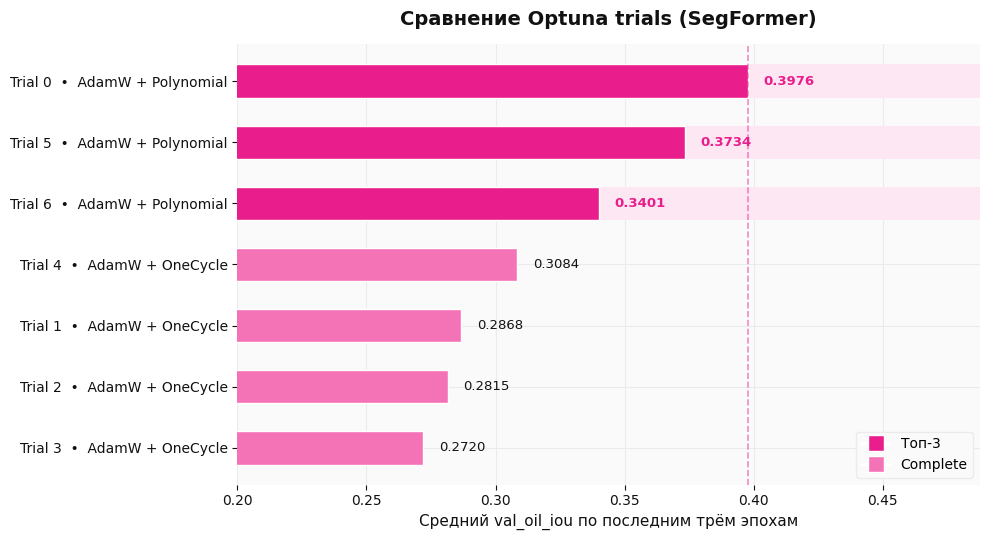

In [5]:
# График 1: Сравнение Optuna trials по val_oil_iou

trials_data = [
    (0, 'AdamW', 'Polynomial', 0.3976, 'complete'),
    (1, 'AdamW', 'OneCycle',   0.2868, 'complete'),
    (2, 'AdamW', 'OneCycle',   0.2815, 'complete'),
    (3, 'AdamW', 'OneCycle',   0.2720, 'complete'),
    (4, 'AdamW', 'OneCycle',   0.3084, 'complete'),
    (5, 'AdamW', 'Polynomial', 0.3734, 'complete'),
    (6, 'AdamW', 'Polynomial', 0.3401, 'complete'),
]

trials_data_sorted = sorted(trials_data, key=lambda x: x[3])
trial_labels = [f"Trial {t[0]}  •  {t[1]} + {t[2]}" for t in trials_data_sorted]
iou_values = [t[3] for t in trials_data_sorted]
states = [t[4] for t in trials_data_sorted]

complete_iou = sorted(
    [(t[3], i) for i, t in enumerate(trials_data_sorted) if t[4] == 'complete'],
    reverse=True
)
top3_indices = {idx for _, idx in complete_iou[:3]}

bar_colors = []
for i, state in enumerate(states):
    if i in top3_indices:
        bar_colors.append(C_PINK)
    elif state == 'pruned':
        bar_colors.append(C_GRAY)
    else:
        bar_colors.append(C_PINK_SOFT)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')

bars = ax.barh(
    trial_labels, iou_values,
    color=bar_colors,
    edgecolor='white',
    height=0.55,
    zorder=3
)

for i in top3_indices:
    ax.barh(
        trial_labels[i], 1.0,
        color=C_PINK_BG,
        height=0.55,
        zorder=2,
        left=0
    )
    ax.barh(
        trial_labels[i], iou_values[i],
        color=C_PINK,
        edgecolor='white',
        height=0.55,
        zorder=3
    )

for bar, val, i in zip(bars, iou_values, range(len(iou_values))):
    ax.text(
        val + 0.006,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left',
        fontsize=9.5,
        color=C_PINK if i in top3_indices else C_GRAY_DARK,
        fontweight='bold' if i in top3_indices else 'normal'
    )

best_val = max(iou_values)
ax.axvline(best_val, color=C_PINK, linewidth=1.2, linestyle='--', alpha=0.5, zorder=4)

ax.set_xlabel('Средний val_oil_iou по последним трём эпохам')
ax.set_xlim(0.20, max(iou_values) + 0.09)
ax.set_title('Сравнение Optuna trials (SegFormer)')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_PINK,      markersize=11, label='Топ-3'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_PINK_SOFT, markersize=11, label='Complete'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('stage1_optuna_trials.png')
plt.show()

### Вывод по подбору гиперпараметров с Optuna (7 trials, 5 эпох)

По результатам поиска отчётливо прослеживается закономерность: все три лучшие конфигурации (Trial 0, 5, 6) используют планировщик **Polynomial**, в то время как все четыре конфигурации с **OneCycle** показали заметно более низкий результат — разрыв между лучшим OneCycle-триалом (0.3084) и худшим Polynomial-триалом (0.3401) составляет более 0.03 по `val_oil_iou`. Это говорит о том, что для архитектуры SegFormer на данной задаче планировщик Polynomial подходит существенно лучше, чем агрессивное OneCycle-расписание

Победителем поиска стал **Trial 0** (`lr=1.47e-04`, `weight_decay=2.56e-02`, Polynomial, AdamW) со средним `val_oil_iou=0.3976` за последние три эпохи — именно эта и ещё две следующие по качеству конфигурации (Trial 5, Trial 6) были отобраны для подтверждающих запусков на следующем шаге

Стоит отметить масштаб поиска (7 триалов) — это даёт лишь приблизительное представление о пространстве гиперпараметров, а не исчерпывающий охват, что является осознанным компромиссом в условиях ограниченных ресурсов

## Шаг 2: подтверждающие прогоны топ-3 (10 эпох каждый)

Обучает топ-3 конфигурации Optuna по 10 эпох, чтобы отсеять случайно удачные результаты на 5 эпохах.  
RUN_ID 2, 3, 4. **Победитель определяется по среднему `val_oil_iou` за последние 3 эпохи (эпохи 8–9–10)** — аналогично Стадии 2 UNet.

In [ ]:
CONFIRM_EPOCHS   = 10
CONFIRM_RUN_IDS  = [2, 3, 4]
confirm_results  = {}

In [12]:
def build_optimizer_and_scheduler(
    model: nn.Module,
    config: dict,
    n_train_batches: int,
):
    """
    Настраивает оптимизатор и scheduler для обучения модели
    """
    param_groups = build_param_groups(model, config)

    if config['OPTIMIZER'] == 'AdamW':
        optimizer = torch.optim.AdamW(param_groups)
    else:
        optimizer = torch.optim.SGD(param_groups, momentum=0.9, nesterov=True)

    max_ep = config['MAX_EPOCHS']
    sched_name = config['SCHEDULER']

    if sched_name == 'polynomial':
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer, total_iters=max_ep, power=1.0
        )
        is_onecycle = False
    elif sched_name == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max_ep, eta_min=1e-7
        )
        is_onecycle = False
    else:  
        max_lrs = [pg['lr'] for pg in param_groups]
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lrs,
            epochs=max_ep,
            steps_per_epoch=n_train_batches,
            pct_start=0.3,
        )
        is_onecycle = True

    return optimizer, scheduler, is_onecycle


def train_flexible(config: dict) -> list[dict]:
    """
    Цикл обучения модели с сохранением метрик и чекпоинтов
    """
    seed_everything(config['SEED'])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    run_id = config['RUN_ID']
    log_path = WORK_DIR / f'segformer_run{run_id}_log.json'

    print(f'\n{"="*70}')
    print(f'RUN_ID={run_id} | {config["BACKBONE"]} | {config["OPTIMIZER"]} | '
          f'{config["SCHEDULER"]} | lr={config["LR"]:.2e} | wd={config["WEIGHT_DECAY"]:.2e}')
    print(f'макс_эпох={config["MAX_EPOCHS"]}  сид={config["SEED"]}')
    print(f'{"="*70}')

    train_inv_raw = pd.read_csv(TRAIN_INV_PATH)
    val_inv = pd.read_csv(VAL_INV_PATH)
    train_inv = oversample(train_inv_raw, ratio='1:1', seed=config['SEED'])
    train_loader, val_loader = make_loaders(
        train_inv, val_inv, batch_size=config['BATCH_SIZE']
    )

    model = build_model(config).to(device)

    optimizer, scheduler, is_onecycle = build_optimizer_and_scheduler(
        model, config, n_train_batches=len(train_loader)
    )
    criterion = build_loss().to(device)

    start_epoch, best_val_iou, history = load_checkpoint(
        run_id, model, optimizer, scheduler, device
    )

    patience_counter = 0
    best_epoch = start_epoch - 1
    max_ep = config['MAX_EPOCHS']

    epoch_bar = tqdm(
        range(start_epoch, max_ep),
        desc=f'RUN {run_id} [{config["BACKBONE"]}]',
        unit='epoch', dynamic_ncols=True,
        initial=start_epoch, total=max_ep,
    )
    for epoch in epoch_bar:
        train_loss, _, _ = run_epoch(
            model, train_loader, criterion, optimizer,
            device, is_train=True, grad_clip=config['GRAD_CLIP'],
            scheduler=scheduler, onecycle=is_onecycle,
        )
        val_loss, val_oil, val_bg = run_epoch(
            model, val_loader, criterion, optimizer,
            device, is_train=False,
        )

        if not is_onecycle:
            scheduler.step()

        enc_lr = optimizer.param_groups[0]['lr']
        dec_lr = optimizer.param_groups[1]['lr']
        epoch_bar.set_postfix({
            'tr_loss': f'{train_loss:.4f}',
            'vl_loss': f'{val_loss:.4f}',
            'oil_iou': f'{val_oil:.4f}',
            'bg_iou' : f'{val_bg:.4f}',
        })
        tqdm.write(
            f'  Эпоха {epoch+1:>3}/{max_ep} | '
            f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
            f'val_oil_iou={val_oil:.4f}  val_background_iou={val_bg:.4f}  '
            f'enc_lr={enc_lr:.2e}  dec_lr={dec_lr:.2e}'
        )

        is_best = val_oil > best_val_iou
        if is_best:
            best_val_iou = val_oil
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        epoch_record = dict(
            phase = 'train_flexible',
            run_id = run_id,
            backbone = config['BACKBONE'],
            epoch = epoch + 1,
            train_loss = train_loss,
            val_loss = val_loss,
            val_oil_iou = val_oil,
            val_background_iou = val_bg,
            enc_lr = enc_lr,
            dec_lr = dec_lr,
        )
        history.append(epoch_record)

        save_checkpoint(
            run_id, model, optimizer, scheduler,
            epoch, best_val_iou, history, is_best,
        )

        existing_log = []
        if log_path.exists():
            with open(log_path) as f:
                existing_log = json.load(f)
        existing_log.append(epoch_record)
        with open(log_path, 'w') as f:
            json.dump(existing_log, f, indent=2)

        torch.cuda.empty_cache()
        gc.collect()

        if patience_counter >= config['PATIENCE']:
            print(f'[Ранняя остановка] эпоха {epoch+1}, best_val_iou={best_val_iou:.4f}')
            break

    print(f'\nГотово - RUN_ID={run_id}  best_val_iou={best_val_iou:.4f} (эпоха {best_epoch+1})')
    return history


def last3_avg_iou(history: list[dict]) -> float:
    """Средний val_oil_iou за последние 3 эпохи"""
    ious = [r['val_oil_iou'] for r in history if 'val_oil_iou' in r]
    return float(np.mean(ious[-3:])) if len(ious) >= 3 else float(np.mean(ious))

### Проверочный запуск № 1

In [20]:
rank, run_id = 1, CONFIRM_RUN_IDS[0]
params = TOP3_PARAMS[0]
print(f'\n--- Подтверждающий запуск #{rank} (RUN_ID={run_id}) ---')
confirm_config = dict(
    RUN_ID = run_id,
    BACKBONE = BACKBONE,
    ENCODER_WEIGHTS = None,
    LR = params['lr'],
    LR_ENCODER_MULT = 0.1,
    WEIGHT_DECAY = params['weight_decay'],
    BATCH_SIZE = 16,
    MAX_EPOCHS = CONFIRM_EPOCHS,
    PATIENCE = CONFIRM_EPOCHS, 
    GRAD_CLIP = 1.0,
    SCHEDULER = params['scheduler'],
    OPTIMIZER = 'AdamW',
    SEED = SEED,
)

history_confirm = train_flexible(confirm_config)


--- Подтверждающий запуск #1 (RUN_ID=2) ---

RUN_ID=2 | mit_b1 | AdamW | polynomial | lr=1.47e-04 | wd=2.56e-02
макс_эпох=10  сид=42
оверсэмплинг: нефть=5808  фон=27088→5808  итого=11616
Загрузчики: train=726 батчей  val=514 батчей  batch_size=16
Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Возобновляем с segformer_run2_epoch.pt (эпоха=9, best_val_iou=0.4860)


RUN 2 [mit_b1]: 100%|##########| 10/10 [00:00<?, ?epoch/s]


Готово - RUN_ID=2  best_val_iou=0.4860 (эпоха 10)


In [21]:
res = evaluate_run(confirm_config)

Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Загружены лучшие веса из segformer_run2_best.pt (val_oil_iou=0.4860)

════════════════════════════════════════════════════════════
evaluate_run - RUN_ID=2 (mit_b1)
Лучший чекпоинт val_oil_iou: 0.4860
════════════════════════════════════════════════════════════
  val_oil_iou              0.4860
  val_background_iou       0.9901
  val_mean_iou             0.7380
  val_oil_dice             0.5400
════════════════════════════════════════════════════════════
Метрики после обучения добавлены → /kaggle/working/segformer_run2_log.json


In [22]:
confirm_results[run_id] = {
    'config': confirm_config,
    'metrics': res,
    'history': history_confirm,
    'last3_avg': float(np.mean([r['val_oil_iou'] for r in history_confirm][-3:])),
}

### Проверочный запуск № 2

In [23]:
rank, run_id = 2, CONFIRM_RUN_IDS[1]
params = TOP3_PARAMS[1]
print(f'\n--- Подтверждающий запуск #{rank} (RUN_ID={run_id}) ---')
confirm_config = dict(
    RUN_ID = run_id,
    BACKBONE = BACKBONE,
    ENCODER_WEIGHTS = None,
    LR = params['lr'],
    LR_ENCODER_MULT = 0.1,
    WEIGHT_DECAY = params['weight_decay'],
    BATCH_SIZE = 16,
    MAX_EPOCHS = CONFIRM_EPOCHS,
    PATIENCE = CONFIRM_EPOCHS,
    GRAD_CLIP = 1.0,
    SCHEDULER = params['scheduler'],
    OPTIMIZER = 'AdamW',
    SEED = SEED,
)

history_confirm = train_flexible(confirm_config)


--- Подтверждающий запуск #2 (RUN_ID=3) ---

RUN_ID=3 | mit_b1 | AdamW | polynomial | lr=2.93e-05 | wd=1.56e-04
макс_эпох=10  сид=42
оверсэмплинг: нефть=5808  фон=27088→5808  итого=11616
Загрузчики: train=726 батчей  val=514 батчей  batch_size=16
Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Возобновляем с segformer_run3_epoch.pt (эпоха=9, best_val_iou=0.4125)


RUN 3 [mit_b1]: 100%|##########| 10/10 [00:00<?, ?epoch/s]


Готово - RUN_ID=3  best_val_iou=0.4125 (эпоха 10)


In [24]:
res = evaluate_run(confirm_config)

Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Загружены лучшие веса из segformer_run3_best.pt (val_oil_iou=0.4125)

════════════════════════════════════════════════════════════
evaluate_run - RUN_ID=3 (mit_b1)
Лучший чекпоинт val_oil_iou: 0.4125
════════════════════════════════════════════════════════════
  val_oil_iou              0.4125
  val_background_iou       0.9792
  val_mean_iou             0.6959
  val_oil_dice             0.4684
════════════════════════════════════════════════════════════
Метрики после обучения добавлены → /kaggle/working/segformer_run3_log.json


In [25]:
confirm_results[run_id] = {
    'config': confirm_config,
    'metrics': res,
    'history': history_confirm,
    'last3_avg': float(np.mean([r['val_oil_iou'] for r in history_confirm][-3:])),
}

### Проверочный запуск № 3

In [27]:
rank, run_id = 3, CONFIRM_RUN_IDS[2]
params = TOP3_PARAMS[2]
print(f'\n--- Подтверждающий запуск #{rank} (RUN_ID={run_id}) ---')
confirm_config = dict(
    RUN_ID = run_id,
    BACKBONE = BACKBONE,
    ENCODER_WEIGHTS = None,
    LR = params['lr'],
    LR_ENCODER_MULT = 0.1,
    WEIGHT_DECAY = params['weight_decay'],
    BATCH_SIZE = 16,
    MAX_EPOCHS = CONFIRM_EPOCHS,
    PATIENCE = CONFIRM_EPOCHS,
    GRAD_CLIP = 1.0,
    SCHEDULER = params['scheduler'],
    OPTIMIZER = 'AdamW',
    SEED = SEED,
)

history_confirm = train_flexible(confirm_config)


--- Подтверждающий запуск #3 (RUN_ID=4) ---

RUN_ID=4 | mit_b1 | AdamW | polynomial | lr=2.14e-05 | wd=7.28e-03
макс_эпох=10  сид=42
оверсэмплинг: нефть=5808  фон=27088→5808  итого=11616
Загрузчики: train=726 батчей  val=514 батчей  batch_size=16
Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Чекпоинт для RUN_ID=4 не найден - начинаем с нуля


RUN 4 [mit_b1]:   0%|          | 0/10 [00:00<?, ?epoch/s]

Обучение:   0%|          | 0/726 [00:00<?, ?batch/s]

Валидация:   0%|          | 0/514 [00:00<?, ?batch/s]

  Эпоха   1/10 | train_loss=0.7052  val_loss=0.5453  val_oil_iou=0.2168  val_background_iou=0.9153  enc_lr=1.93e-06  dec_lr=1.93e-05
[ckpt] сохранён → /kaggle/working/segformer_run4_epoch.pt (эпоха 1)


...

Обучение:   0%|          | 0/726 [00:00<?, ?batch/s]

Валидация:   0%|          | 0/514 [00:00<?, ?batch/s]

  Эпоха  10/10 | train_loss=0.4349  val_loss=0.4109  val_oil_iou=0.3910  val_background_iou=0.9792  enc_lr=0.00e+00  dec_lr=0.00e+00
[ckpt] сохранён → /kaggle/working/segformer_run4_epoch.pt (эпоха 10)


/kaggle/working/segformer_run4_epoch.pt


Готово - RUN_ID=4  best_val_iou=0.4011 (эпоха 8)


In [30]:
res = evaluate_run(confirm_config)

Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Загружены лучшие веса из segformer_run4_best.pt (val_oil_iou=0.4011)

════════════════════════════════════════════════════════════
evaluate_run - RUN_ID=4 (mit_b1)
Лучший чекпоинт val_oil_iou: 0.4011
════════════════════════════════════════════════════════════
  val_oil_iou              0.4011
  val_background_iou       0.9781
  val_mean_iou             0.6896
  val_oil_dice             0.4573
════════════════════════════════════════════════════════════
Метрики после обучения добавлены → /kaggle/working/segformer_run4_log.json


In [31]:
confirm_results[run_id] = {
    'config': confirm_config,
    'metrics': res,
    'history': history_confirm,
    'last3_avg': float(np.mean([r['val_oil_iou'] for r in history_confirm][-3:])),
}

In [32]:
print(f'\n{"═"*70}')
print('ШАГ 2 — РЕЗУЛЬТАТЫ ПОДТВЕРЖДЕНИЯ')
print(f'{"═"*70}')
header = f'{"#":<4} {"RUN_ID":<8} {"val_oil_iou":>14} {"val_bg_iou":>14} {"val_mean_iou":>14} {"val_oil_dice":>14}'
print(header)
print('─' * 70)
confirm_ranked = sorted(
    confirm_results.items(),
    key=lambda x: x[1]['last3_avg'],
    reverse=True,
)
for rank, (run_id, data) in enumerate(confirm_ranked, 1):
    m = data['metrics']
    print(
        f'{rank:<4} {run_id:<8} '
        f'{data["last3_avg"]:>15.4f} '
        f'{m["val_oil_iou"]:>15.4f} '
        f'{m["val_oil_dice"]:>14.4f}'
    )
print(f'{"═"*70}')
WINNER_RUN_ID = confirm_ranked[0][0]
WINNER_CONFIG = confirm_ranked[0][1]['config']
WINNER_METRICS = confirm_ranked[0][1]['metrics']
print(f'\n>>> WINNER: RUN_ID={WINNER_RUN_ID} | val_oil_iou={WINNER_METRICS["val_oil_iou"]:.4f}')
print(f'lr={WINNER_CONFIG["LR"]:.2e}  wd={WINNER_CONFIG["WEIGHT_DECAY"]:.2e}  '
      f'sched={WINNER_CONFIG["SCHEDULER"]}  opt={WINNER_CONFIG["OPTIMIZER"]}')


══════════════════════════════════════════════════════════════════════
ШАГ 2 — РЕЗУЛЬТАТЫ ПОДТВЕРЖДЕНИЯ
══════════════════════════════════════════════════════════════════════
#    RUN_ID      val_oil_iou     val_bg_iou   val_mean_iou   val_oil_dice
──────────────────────────────────────────────────────────────────────
1    2                 0.4539          0.4860         0.5400
2    3                 0.4043          0.4125         0.4684
3    4                 0.3929          0.4011         0.4573
══════════════════════════════════════════════════════════════════════

>>> WINNER: RUN_ID=2 | val_oil_iou=0.4860
lr=1.47e-04  wd=2.56e-02  sched=polynomial  opt=AdamW


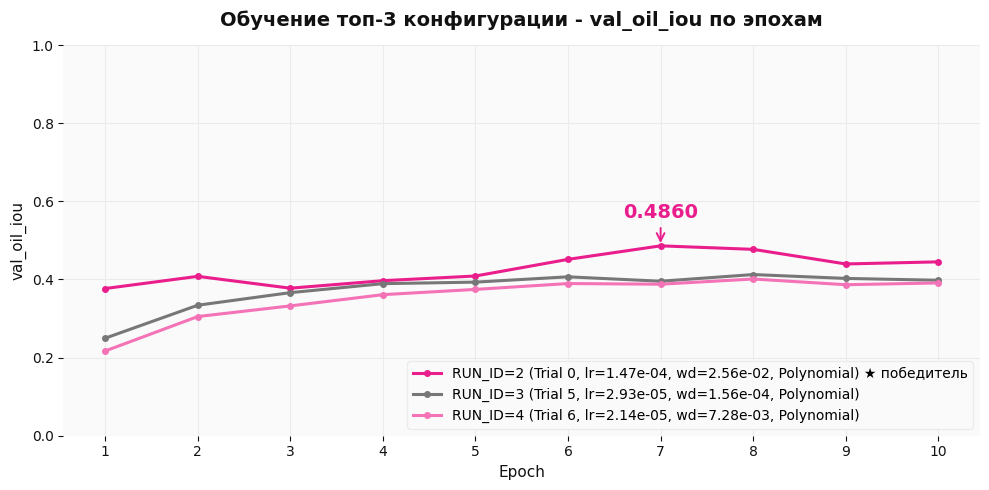

In [8]:
# График 2: Подтверждающие запуски - val_oil_iou по эпохам
epochs_2 = list(range(1, 11))
epochs_3 = list(range(1, 11))
epochs_4 = list(range(1, 11))
oil_iou_2 = [0.3767, 0.4079, 0.3776, 0.3968, 0.4088, 0.4514, 0.4860, 0.4770, 0.4396, 0.4450]
oil_iou_3 = [0.2496, 0.3340, 0.3662, 0.3892, 0.3931, 0.4067, 0.3954, 0.4125, 0.4026, 0.3979]
oil_iou_4 = [0.2168, 0.3050, 0.3323, 0.3610, 0.3745, 0.3895, 0.3878, 0.4011, 0.3865, 0.3910]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_2, oil_iou_2, color=C_PINK, marker='o', markersize=4,
        label='RUN_ID=2 (Trial 0, lr=1.47e-04, wd=2.56e-02, Polynomial) ★ победитель')
ax.plot(epochs_3, oil_iou_3, color=C_GRAY, marker='o', markersize=4,
        label='RUN_ID=3 (Trial 5, lr=2.93e-05, wd=1.56e-04, Polynomial)')
ax.plot(epochs_4, oil_iou_4, color=C_PINK_SOFT, marker='o', markersize=4,
        label='RUN_ID=4 (Trial 6, lr=2.14e-05, wd=7.28e-03, Polynomial)')

peak_epoch_2 = oil_iou_2.index(max(oil_iou_2)) + 1
peak_val_2 = max(oil_iou_2)
ax.annotate(f'{peak_val_2:.4f}', xy=(peak_epoch_2, peak_val_2),
            xytext=(peak_epoch_2, peak_val_2 + 0.07),
            fontsize=14, color=C_PINK, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=C_PINK, lw=1.4))

ax.set_xlabel('Epoch')
ax.set_ylabel('val_oil_iou')
ax.set_title('Обучение топ-3 конфигурации - val_oil_iou по эпохам')
ax.set_xticks(list(range(1, 11)))
ax.set_ylim(0, 1.0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('stage2_val_oil_iou.png')
plt.show()

### Топ-3 конфигурации - val_oil_iou по эпохам

Подтверждение на полных 10 эпохах подтвердило результат поиска Optuna: **RUN_ID=2 (Trial 0, lr=1.47e-04, wd=2.56e-02, Polynomial)** уверенно лидирует на протяжении почти всего обучения, достигая пика `val_oil_iou=0.486` на 7-й эпохе - заметно выше двух других конфигураций, которые на протяжении всего обучения держатся близко друг к другу в диапазоне 0.39–0.41

При более длительном обучении (10 эпох против 5 в Optuna) разрыв между конфигурациями стал более выраженным, чем показывал краткий поиск. Это как раз подтверждает, что 5-эпохового бюджета Optuna было достаточно для выявления верного направления, но недостаточно для полной оценки итогового потенциала конфигурации. RUN_ID=3 и RUN_ID=4, использующие значительно меньший learning rate (2.93e-05 и 2.14e-05 соответственно), показывают более медленный и стабильный, но в итоге менее результативный рост

По итогам этого этапа конфигурация **Trial 0** была окончательно выбрана как победитель для финального 50-эпохового обучения

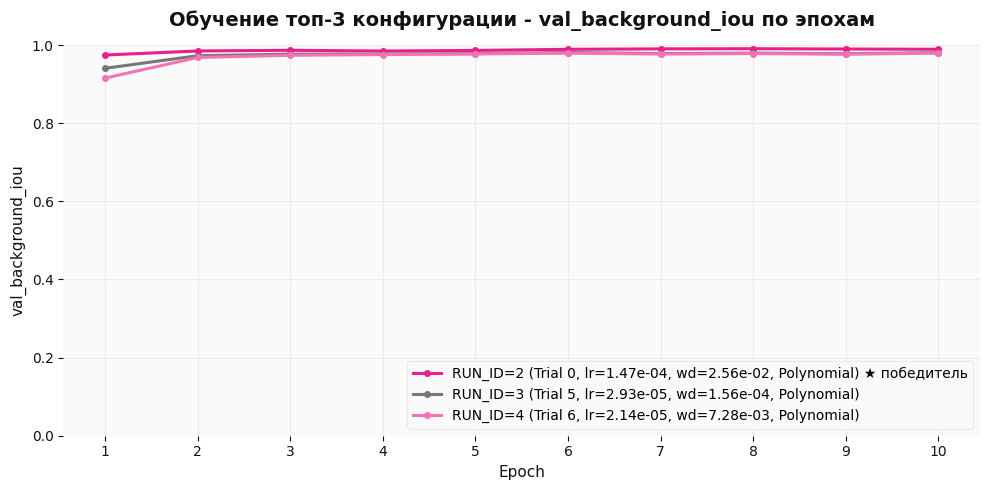

In [18]:
# График 3: Подтверждающие запуски - val_background_iou по эпохам
bg_iou_2 = [0.9744, 0.9847, 0.9865, 0.9846, 0.9861, 0.9890, 0.9901, 0.9905, 0.9897, 0.9891]
bg_iou_3 = [0.9404, 0.9726, 0.9766, 0.9769, 0.9779, 0.9808, 0.9782, 0.9792, 0.9778, 0.9805]
bg_iou_4 = [0.9153, 0.9681, 0.9737, 0.9755, 0.9771, 0.9792, 0.9767, 0.9781, 0.9763, 0.9792]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs_2, bg_iou_2, color=C_PINK,      marker='o', markersize=4,
        label='RUN_ID=2 (Trial 0, lr=1.47e-04, wd=2.56e-02, Polynomial) ★ победитель')
ax.plot(epochs_3, bg_iou_3, color=C_GRAY,      marker='o', markersize=4,
        label='RUN_ID=3 (Trial 5, lr=2.93e-05, wd=1.56e-04, Polynomial)')
ax.plot(epochs_4, bg_iou_4, color=C_PINK_SOFT, marker='o', markersize=4,
        label='RUN_ID=4 (Trial 6, lr=2.14e-05, wd=7.28e-03, Polynomial)')

ax.set_xlabel('Epoch')
ax.set_ylabel('val_background_iou')
ax.set_title('Обучение топ-3 конфигурации - val_background_iou по эпохам')
ax.set_xticks(list(range(1, 11)))
ax.set_ylim(0, 1.0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('stage2_val_background_iou.png')
plt.show()

### Топ-3 конфигурации - val_background_iou по эпохам

Все три конфигурации демонстрируют схожую, стабильно высокую динамику по фону,`val_background_iou` уже к 3-й эпохе выходит на плато выше 0.97 и остаётся там до конца обучения для всех трёх запусков. Это ожидаемо: фон значительно преобладает по площади над нефтью, поэтому модель быстро обучается корректно классифицировать фоновые пиксели независимо от конкретной конфигурации гиперпараметров

Важный вывод: высокий и почти неразличимый `val_background_iou` между всеми тремя конфигурациями подтверждает, что именно `val_oil_iou` (а не background-метрика) является информативным критерием для выбора лучшей конфигурации. Этот график показывает, что различия между запусками практически не отражаются на способности модели распознавать фон, и реальная конкуренция между конфигурациями разворачивается исключительно вокруг качества сегментации непосредственно нефти

## Шаг 3: финальное обучение (50 эпох)
Обучает конфигурацию-победитель из Шага 2 (топ-1 подтверждённая конфигурация) в течение **50 эпох**.  
RUN_ID=5. Ранняя остановка с patience=10 на `val_oil_iou` (страховочный механизм — в норме все 50 эпох завершаются)

Чекпоинт сохраняется каждую эпоху (rolling) + отдельный `best_` при улучшении `val_oil_iou` 
Все метрики мониторинга логируются в `segformer_run5_log.json` после каждой эпохи

In [13]:
WINNER_CONFIG = dict(
    LR=1.47e-04,
    WEIGHT_DECAY=2.56e-02,
    SCHEDULER='polynomial',
    OPTIMIZER='AdamW',
    BACKBONE='mit_b1',
)

In [14]:
FINAL_TRAIN_RUN_ID = 5
FINAL_TRAIN_EPOCHS = 50
FINAL_PATIENCE = 10  
FINAL_SEED = SEED  

print(f'Шаг 3 — финальное обучение')
print(f'RUN_ID={FINAL_TRAIN_RUN_ID} | сид={FINAL_SEED} | эпох={FINAL_TRAIN_EPOCHS}')
print(f'Конфигурация: lr={WINNER_CONFIG["LR"]:.2e}  wd={WINNER_CONFIG["WEIGHT_DECAY"]:.2e}  '
      f'sched={WINNER_CONFIG["SCHEDULER"]}  opt={WINNER_CONFIG["OPTIMIZER"]}')

final_train_config = dict(
    RUN_ID = FINAL_TRAIN_RUN_ID,
    BACKBONE = WINNER_CONFIG['BACKBONE'],
    ENCODER_WEIGHTS = None,
    LR = WINNER_CONFIG['LR'],
    LR_ENCODER_MULT = 0.1,
    WEIGHT_DECAY = WINNER_CONFIG['WEIGHT_DECAY'],
    BATCH_SIZE = 16,
    MAX_EPOCHS = FINAL_TRAIN_EPOCHS,
    PATIENCE = FINAL_PATIENCE,
    GRAD_CLIP = 1.0,
    SCHEDULER = WINNER_CONFIG['SCHEDULER'],
    OPTIMIZER = WINNER_CONFIG['OPTIMIZER'],
    SEED = FINAL_SEED,
)

history_final = train_flexible(final_train_config)

Шаг 3 — финальное обучение
RUN_ID=5 | сид=42 | эпох=50
Конфигурация: lr=1.47e-04  wd=2.56e-02  sched=polynomial  opt=AdamW

RUN_ID=5 | mit_b1 | AdamW | polynomial | lr=1.47e-04 | wd=2.56e-02
макс_эпох=50  сид=42
оверсэмплинг: нефть=5808  фон=27088→5808  итого=11616
Загрузчики: train=726 батчей  val=514 батчей  batch_size=16
Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Чекпоинт для RUN_ID=5 не найден - начинаем с нуля


RUN 5 [mit_b1]:   0%|          | 0/50 [00:00<?, ?epoch/s]

Обучение:   0%|          | 0/726 [00:00<?, ?batch/s]

Валидация:   0%|          | 0/514 [00:00<?, ?batch/s]

  Эпоха   1/50 | train_loss=0.5278  val_loss=0.4203  val_oil_iou=0.3788  val_background_iou=0.9745  enc_lr=1.44e-05  dec_lr=1.44e-04
[ckpt] сохранён → /kaggle/working/segformer_run5_epoch.pt (эпоха 1)


...

Обучение:   0%|          | 0/726 [00:00<?, ?batch/s]

Валидация:   0%|          | 0/514 [00:00<?, ?batch/s]

  Эпоха  18/50 | train_loss=0.2416  val_loss=0.4420  val_oil_iou=0.4804  val_background_iou=0.9909  enc_lr=9.41e-06  dec_lr=9.41e-05
[ckpt] сохранён → /kaggle/working/segformer_run5_epoch.pt (эпоха 18)


/kaggle/working/segformer_run5_epoch.pt

[Ранняя остановка] эпоха 18, best_val_iou=0.5503

Готово - RUN_ID=5  best_val_iou=0.5503 (эпоха 8)


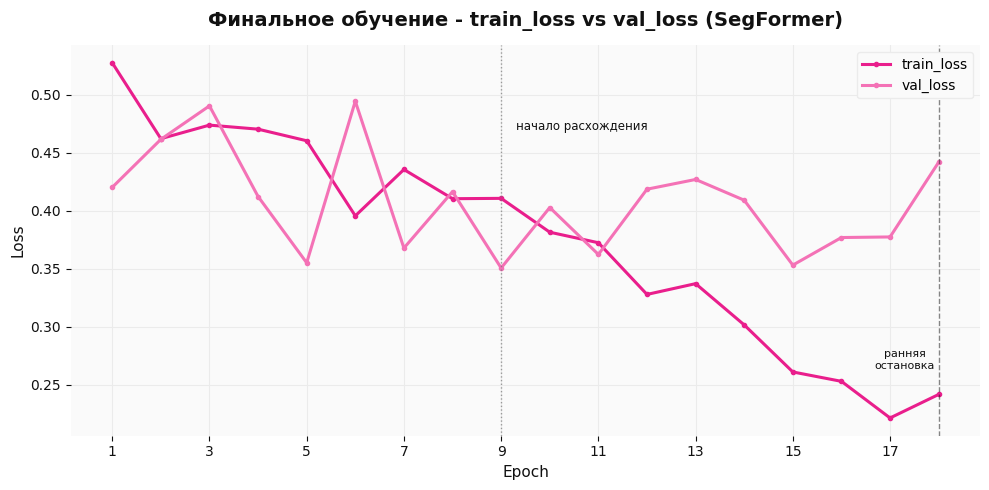

In [11]:
# График 4: Финальное обучение - train_loss vs val_loss

epochs = list(range(1, 19))

train_loss = [0.5278, 0.4623, 0.4740, 0.4705, 0.4605, 0.3957, 0.4357, 0.4105, 0.4108,
              0.3816, 0.3725, 0.3279, 0.3372, 0.3016, 0.2610, 0.2529, 0.2213, 0.2416]

val_loss   = [0.4203, 0.4617, 0.4906, 0.4124, 0.3552, 0.4946, 0.3679, 0.4166, 0.3507,
              0.4029, 0.3624, 0.4187, 0.4271, 0.4092, 0.3532, 0.3770, 0.3775, 0.4420]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, train_loss, color=C_PINK,      marker='o', markersize=3, label='train_loss')
ax.plot(epochs, val_loss,   color=C_PINK_SOFT, marker='o', markersize=3, label='val_loss')

ax.axvline(9, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)
ax.text(9.3, max(val_loss) * 0.95, 'начало расхождения', fontsize=8.5, color=C_GRAY_DARK)

# Эпоха ранней остановки (best_epoch=8, остановка на эпохе 18)
ax.axvline(18, color=C_GRAY_DARK, linewidth=1.0, linestyle='--', alpha=0.5)
ax.text(17.3, max(train_loss) * 0.5, 'ранняя\nостановка', fontsize=8, color=C_GRAY_DARK, ha='center')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Финальное обучение - train_loss vs val_loss (SegFormer)')
ax.set_xticks(list(range(1, 19, 2)))
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('final_train_val_loss.png')
plt.show()

### Финальное обучение — train_loss vs val_loss

После эпохи 9 кривые `train_loss` и `val_loss` устойчиво расходятся: `train_loss` продолжает монотонно снижаться (с 0.41 до 0.22 к 17-й эпохе), в то время как `val_loss` колеблется в диапазоне 0.35–0.44 без выраженного улучшения - классический признак переобучения модели на тренировочных данных без сопоставимого роста обобщающей способности

Ранняя остановка сработала на 18-й эпохе (patience=10 без улучшения `val_oil_iou`). Важно, что итоговая модель для оценки берётся не с последней (переобученной) эпохи, а с лучшего чекпоинта по `val_oil_iou` (эпоха 8) и таким образом, наблюдаемое расхождение лоссов не повлияло на качество финально отобранной модели

Это поведение ожидаемо для трансформерной архитектуры, обучаемой с нуля на относительно небольшом датасете, так как модель находит разумное решение относительно рано, после чего начинает использовать оставшуюся ёмкость для запоминания шума тренировочной выборки, а не для дальнейшего обобщения

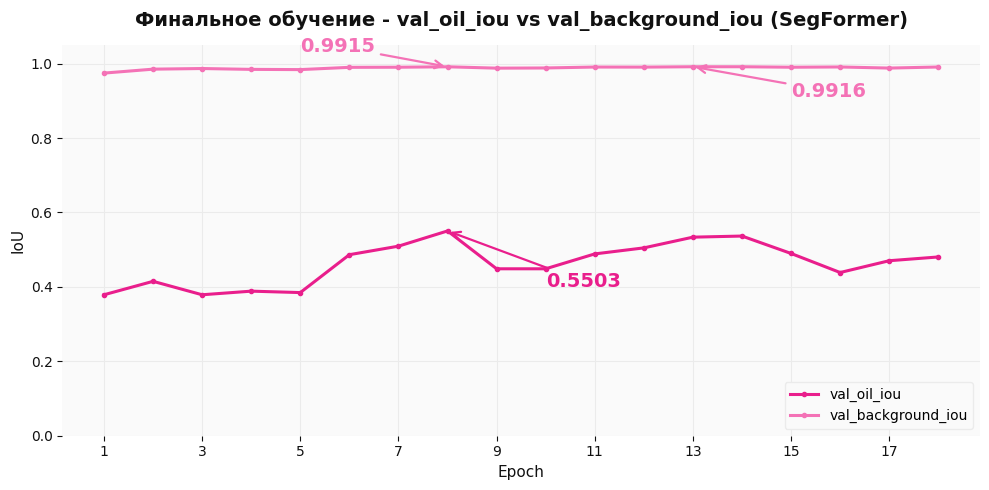

In [16]:
# График 5: Финальное обучение - val_oil_iou vs val_background_iou

val_oil_iou = [0.3788, 0.4149, 0.3788, 0.3885, 0.3847, 0.4865, 0.5094, 0.5503, 0.4486,
               0.4486, 0.4886, 0.5048, 0.5336, 0.5366, 0.4898, 0.4386, 0.4703, 0.4804]

val_bg_iou  = [0.9745, 0.9851, 0.9868, 0.9845, 0.9839, 0.9900, 0.9903, 0.9915, 0.9878,
               0.9883, 0.9908, 0.9906, 0.9916, 0.9916, 0.9903, 0.9910, 0.9880, 0.9909]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, val_oil_iou, color=C_PINK,      marker='o', markersize=3, label='val_oil_iou')
ax.plot(epochs, val_bg_iou,  color=C_PINK_SOFT, marker='o', markersize=3, label='val_background_iou')

best_epoch_oil = val_oil_iou.index(max(val_oil_iou)) + 1
best_val_oil = max(val_oil_iou)
ax.annotate(f'{best_val_oil:.4f}',
            xy=(best_epoch_oil, best_val_oil),
            xytext=(best_epoch_oil + 2, best_val_oil - 0.15),
            arrowprops=dict(arrowstyle='->', color=C_PINK, lw=1.6),
            fontsize=14, color=C_PINK, fontweight='bold')

best_epoch_bg = val_bg_iou.index(max(val_bg_iou)) + 1
best_val_bg = max(val_bg_iou)
ax.annotate(f'{best_val_bg:.4f}',
            xy=(best_epoch_bg, best_val_bg),
            xytext=(best_epoch_bg + 2, best_val_bg - 0.08),
            arrowprops=dict(arrowstyle='->', color=C_PINK_SOFT, lw=1.6),
            fontsize=14, color=C_PINK_SOFT, fontweight='bold')

# val_background_iou на 8-й эпохе (та же эпоха, что и пик val_oil_iou)
bg_at_epoch8 = val_bg_iou[7]
ax.annotate(f'{bg_at_epoch8:.4f}',
            xy=(8, bg_at_epoch8),
            xytext=(8 - 3, bg_at_epoch8 + 0.04),
            arrowprops=dict(arrowstyle='->', color=C_PINK_SOFT, lw=1.6),
            fontsize=14, color=C_PINK_SOFT, fontweight='bold')

ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title('Финальное обучение - val_oil_iou vs val_background_iou (SegFormer)')
ax.set_xticks(list(range(1, 19, 2)))
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('final_iou_curves.png')
plt.show()

## Финальное обучение - val_oil_iou vs val_background_iou

`val_background_iou` стабильно держится на уровне 0.97–0.99 на протяжении всего обучения, не давая дополнительной информации о реальном прогрессе модели и это ожидаемо, учитывая значительное преобладание фона над нефтью в данных. Реальная динамика обучения видна именно в `val_oil_iou`, тут модель достигает пика 0.5503 на 8-й эпохе, после чего колеблется в диапазоне 0.44–0.54 без устойчивого дальнейшего роста, то есть модель нашла достаточно хорошее решение относительно рано и затем не смогла его существенно улучшить за оставшиеся эпохи

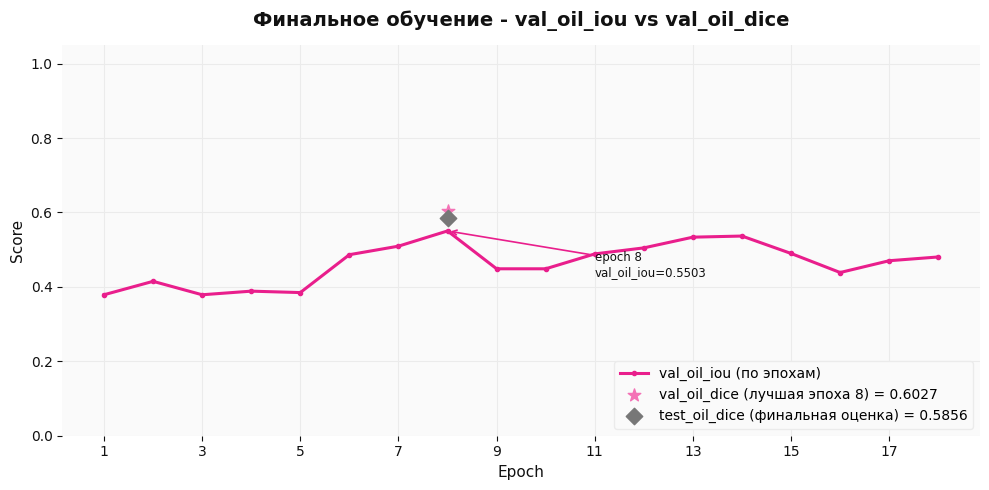

In [13]:
# График 6: Финальное обучение - val_oil_iou vs val_oil_dice

val_oil_dice_best = 0.6027 
val_oil_dice_test = 0.5856 

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, val_oil_iou, color=C_PINK, marker='o', markersize=3, label='val_oil_iou (по эпохам)')

ax.scatter([8], [val_oil_dice_best], color=C_PINK_SOFT, s=90, zorder=5, marker='*',
           label=f'val_oil_dice (лучшая эпоха 8) = {val_oil_dice_best:.4f}')
ax.scatter([8], [val_oil_dice_test], color=C_GRAY, s=70, zorder=5, marker='D',
           label=f'test_oil_dice (финальная оценка) = {val_oil_dice_test:.4f}')

ax.annotate(f'epoch 8\nval_oil_iou={max(val_oil_iou):.4f}',
            xy=(8, max(val_oil_iou)),
            xytext=(11, max(val_oil_iou) - 0.12),
            arrowprops=dict(arrowstyle='->', color=C_PINK, lw=1.2),
            fontsize=8.5, color=C_GRAY_DARK)

ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Финальное обучение - val_oil_iou (по эпохам) vs val_oil_dice')
ax.set_xticks(list(range(1, 19, 2)))
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('final_oil_iou_vs_dice.png')
plt.show()

### Финальное обучение — val_oil_iou vs val_oil_dice

Dice-коэффициент рассчитывался не на каждой эпохе (в отличие от IoU), а только для лучшего чекпоинта (эпоха 8) и итоговой тестовой выборки. На лучшей эпохе `val_oil_dice=0.6027` ожидаемо выше соответствующего `val_oil_iou=0.5503` и это это естественное математическое соотношение между двумя метриками (Dice всегда ≥ IoU при одинаковом предсказании)

Разница между`val_oil_dice`(0.6027) и `test_oil_dice` (0.5856) всего 0.017 является хорошим знаком: модель показывает сопоставимое качество на валидационной и тестовой выборках, что говорит об умеренном переобучении и достаточной обобщающей способности финальной модели, несмотря на отсутствие предобучения и относительно небольшой размер датасета

In [15]:
results_final = evaluate_run(final_train_config)

print(f'\n>>> ФИНАЛЬНОЕ ОБУЧЕНИЕ ЗАВЕРШЕНО')
print(f'val_oil_iou = {results_final["val_oil_iou"]:.4f}')
print(f'val_oil_dice = {results_final["val_oil_dice"]:.4f}')
print(f'val_mean_iou = {results_final["val_mean_iou"]:.4f}')

Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Загружены лучшие веса из segformer_run5_best.pt (val_oil_iou=0.5503)

════════════════════════════════════════════════════════════
evaluate_run - RUN_ID=5 (mit_b1)
Лучший чекпоинт val_oil_iou: 0.5503
════════════════════════════════════════════════════════════
  val_oil_iou              0.5503
  val_background_iou       0.9915
  val_mean_iou             0.7709
  val_oil_dice             0.6027
════════════════════════════════════════════════════════════
Метрики после обучения добавлены → /kaggle/working/segformer_run5_log.json

>>> ФИНАЛЬНОЕ ОБУЧЕНИЕ ЗАВЕРШЕНО
val_oil_iou = 0.5503
val_oil_dice = 0.6027
val_mean_iou = 0.7709


## Шаг 4: финальная оценка
Загружает лучший чекпоинт (`best_`) **финального обучения** (RUN_ID=5, 50 эпох)

In [16]:
# метрики на уровне снимка
def compute_scene_metrics(
    model: nn.Module,
    inventory: pd.DataFrame,
    device: torch.device,
    patch_size: int = PATCH_SIZE,
) -> tuple[float, float]:
    """
    Собирает предсказания патчей в полный снимок 
    и вычисляет средние IoU и Dice по всем снимкам
    """
    model.eval()
    full_size = 2048

    scene_ious = []
    scene_dices = []

    grouped = inventory.groupby('image_path')
    for img_path, group in grouped:
        pred_canvas = np.zeros((full_size, full_size), dtype=np.float32)
        mask_canvas = np.zeros((full_size, full_size), dtype=np.float32)

        for _, row_data in group.iterrows():
            img, mask = load_patch(
                row_data['image_path'],
                row_data['mask_path'],
                int(row_data['row']),
                int(row_data['col']),
                patch_size,
            )
            # нормализуем
            img[:, :, 0] = (img[:, :, 0] - VV_MEAN) / VV_STD
            img[:, :, 1] = (img[:, :, 1] - VH_MEAN) / VH_STD

            transformed = _TRANSFORM(image=img, mask=mask.astype(np.uint8))
            image_t = transformed['image'].float().unsqueeze(0).to(device)  # (1,2,H,W)

            with torch.no_grad():
                logit = model(image_t)   # (1,1,H,W)
                prob = torch.sigmoid(logit).squeeze().cpu().numpy()  # (H,W)

            del image_t, logit

            r, c = int(row_data['row']), int(row_data['col'])
            ph = min(patch_size, full_size - r)
            pw = min(patch_size, full_size - c)
            pred_canvas[r:r+ph, c:c+pw] = prob[:ph, :pw]
            mask_canvas[r:r+ph, c:c+pw] = mask[:ph, :pw]

        pred_bin = (pred_canvas > 0.5).astype(np.float32)
        inter = (pred_bin * mask_canvas).sum()
        union = pred_bin.sum() + mask_canvas.sum() - inter
        iou = float((inter + 1e-7) / (union + 1e-7))

        denom = pred_bin.sum() + mask_canvas.sum()
        dice = float((2.0 * inter + 1e-7) / (denom + 1e-7))

        scene_ious.append(iou)
        scene_dices.append(dice)

    torch.cuda.empty_cache()
    gc.collect()

    return float(np.mean(scene_ious)), float(np.mean(scene_dices))

In [17]:
# финальная оценка
def evaluate_final(
    model: nn.Module,
    val_inventory: pd.DataFrame,
    test_inventory: pd.DataFrame,
    device: torch.device,
    run_id: int,
    config: dict,
) -> tuple[dict, dict]:
    """
    Вычисляет все метрики на уровне патчей и сцен для val и test.
    Вызывается один раз — только на Шаге 4.
    Результаты val и test полностью разделены.
    train_loss извлекается из JSON-лога лучшей эпохи финального обучения.
    Потери сохраняются только в JSON — не выводятся в итоговую таблицу.
    Возвращает (val_metrics, test_metrics).
    """
    criterion = build_loss().to(device)

    def _evaluate_split(
        inventory: pd.DataFrame,
        split_name: str,
    ) -> dict:
        loader = DataLoader(
            OilSpillDataset(inventory),
            batch_size=config['BATCH_SIZE'],
            shuffle=False,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=2,
            worker_init_fn=_worker_init_fn,
        )

        total_loss = 0.0
        sum_oil_iou = 0.0
        sum_bg_iou = 0.0
        sum_oil_dice = 0.0
        n_batches = 0
        model.eval()
        with torch.no_grad():
            for images, masks in loader:
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                logits = model(images)
                total_loss += criterion(logits, masks).item()
                logits_cpu = logits.cpu()
                masks_cpu = masks.cpu()
                sum_oil_iou += oil_iou(logits_cpu, masks_cpu)
                sum_bg_iou += background_iou(logits_cpu, masks_cpu)
                sum_oil_dice += oil_dice(logits_cpu, masks_cpu)
                n_batches += 1
                del images, masks, logits, logits_cpu, masks_cpu

        torch.cuda.empty_cache()
        gc.collect()

        avg_loss = total_loss / len(loader)

        p = split_name
        oil_iou_v = sum_oil_iou / n_batches
        bg_iou_v = sum_bg_iou / n_batches
        mean_iou_v = (oil_iou_v + bg_iou_v) / 2.0
        oil_dice_v = sum_oil_dice / n_batches

        print(f'Вычисляем метрики на уровне сцен для {split_name}...')
        scene_iou_v, scene_dice_v = compute_scene_metrics(model, inventory, device)

        return {
            f'{p}_loss': avg_loss,
            f'{p}_oil_iou': oil_iou_v,
            f'{p}_background_iou': bg_iou_v,
            f'{p}_mean_iou': mean_iou_v,
            f'{p}_oil_dice': oil_dice_v,
            f'{p}_scene_oil_iou': scene_iou_v,
            f'{p}_scene_oil_dice': scene_dice_v,
        }

    print('\nВычисляем метрики на валидации...')
    val_metrics = _evaluate_split(val_inventory, 'val')

    print('\nВычисляем тестовые метрики (тестовая выборка используется впервые и единственный раз)...')
    test_metrics = _evaluate_split(test_inventory, 'test')

    # Загрузка train_loss из JSON-лога финального запуска
    train_loss_final = float('nan')
    try:
        stability_log_path = WORK_DIR / f'segformer_run{run_id}_log.json'
        with open(stability_log_path) as f:
            stability_log = json.load(f)
        # ищу train_loss для лучшей эпохи в post_run_eval
        post_run = next(
            (r for r in stability_log if r.get('phase') == 'post_run_eval'), None
        )
        if post_run and 'train_loss' in post_run:
            train_loss_final = post_run['train_loss']
        else:
            # тут если запись post_run_eval отсутствует, используется лучшая эпоха из истории обучения
            epoch_records = [r for r in stability_log if r.get('phase') == 'train_flexible']
            if epoch_records:
                best_rec = max(epoch_records, key=lambda r: r.get('val_oil_iou', 0))
                train_loss_final = best_rec.get('train_loss', float('nan'))
    except Exception as e:
        print(f'Прудепреждение!: не удалось извлечь train_loss: {e}')

    # сохранение результатов обучения и оценки модели в JSON
    log_path = WORK_DIR / f'segformer_run{run_id}_log.json'
    existing_log = []
    if log_path.exists():
        with open(log_path) as f:
            existing_log = json.load(f)
    existing_log.append({
        'phase': 'final_val',
        'train_loss': train_loss_final,  
        **val_metrics,
    })
    existing_log.append({
        'phase': 'final_test',
        **test_metrics,
    })
    with open(log_path, 'w') as f:
        json.dump(existing_log, f, indent=2)
    print(f'\nФинальные метрики сохранены → {log_path}')

    return val_metrics, test_metrics, train_loss_final

In [18]:
# Финальная оценка обученной модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

final_model = build_model(final_train_config).to(device)


load_best_weights(FINAL_TRAIN_RUN_ID, final_model, device)
final_model.eval()

val_inv = pd.read_csv(VAL_INV_PATH)
test_inv = pd.read_csv(TEST_INV_PATH)

val_final_metrics, test_final_metrics, train_loss_final = evaluate_final(
    final_model, val_inv, test_inv, device,
    run_id=FINAL_TRAIN_RUN_ID,
    config=final_train_config,
)

Модель: SegFormer(mit_b1) | Всего параметров: 13,674,369 | Обучаемых: 13,674,369
[ckpt] Загружены лучшие веса из segformer_run5_best.pt (val_oil_iou=0.5503)

Вычисляем метрики на валидации...
Вычисляем метрики на уровне сцен для val...

Вычисляем тестовые метрики (тестовая выборка используется впервые и единственный раз)...
Вычисляем метрики на уровне сцен для test...

Финальные метрики сохранены → /kaggle/working/segformer_run5_log.json


In [19]:
# Таблица саммари
FINAL_BACKBONE = final_train_config['BACKBONE']

print(f'\n{"═"*72}')
print(f'ШАГ 5 — ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ОЦЕНКИ')
print(f'Бэкбон: {FINAL_BACKBONE} | Сид: {FINAL_SEED} | RUN_ID обучения: {FINAL_TRAIN_RUN_ID}')
print(f'lr={WINNER_CONFIG["LR"]:.2e}  opt={WINNER_CONFIG["OPTIMIZER"]}  '
      f'sched={WINNER_CONFIG["SCHEDULER"]}  wd={WINNER_CONFIG["WEIGHT_DECAY"]:.2e}')
print(f'{"═"*72}')

table_rows = [
    ('Oil IoU',        'val_oil_iou',         'test_oil_iou'),
    ('Background IoU', 'val_background_iou',   'test_background_iou'),
    ('Mean IoU',       'val_mean_iou',          'test_mean_iou'),
    ('Oil Dice',       'val_oil_dice',          'test_oil_dice'),
    ('Scene Oil IoU',  'val_scene_oil_iou',     'test_scene_oil_iou'),
    ('Scene Oil Dice', 'val_scene_oil_dice',    'test_scene_oil_dice'),
]

col_header = f'{"Metric":<22} {"Validation":>14} {"Test":>14}'
print(col_header)
print('─' * 52)
for label, val_key, test_key in table_rows:
    v = val_final_metrics.get(val_key,   float('nan'))
    t = test_final_metrics.get(test_key, float('nan'))
    print(f'{label:<22} {v:>14.4f} {t:>14.4f}')
print(f'{"═"*72}')
print(f'Потери сохранены в JSON (train_loss={train_loss_final:.4f}, val_loss и test_loss)')


════════════════════════════════════════════════════════════════════════
ШАГ 5 — ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ОЦЕНКИ
Бэкбон: mit_b1 | Сид: 42 | RUN_ID обучения: 5
lr=1.47e-04  opt=AdamW  sched=polynomial  wd=2.56e-02
════════════════════════════════════════════════════════════════════════
Metric                     Validation           Test
────────────────────────────────────────────────────
Oil IoU                        0.5503         0.5480
Background IoU                 0.9915         0.9754
Mean IoU                       0.7709         0.7617
Oil Dice                       0.6027         0.5856
Scene Oil IoU                  0.5503         0.5480
Scene Oil Dice                 0.6027         0.5856
════════════════════════════════════════════════════════════════════════
Потери сохранены в JSON (train_loss=0.4105, val_loss и test_loss)


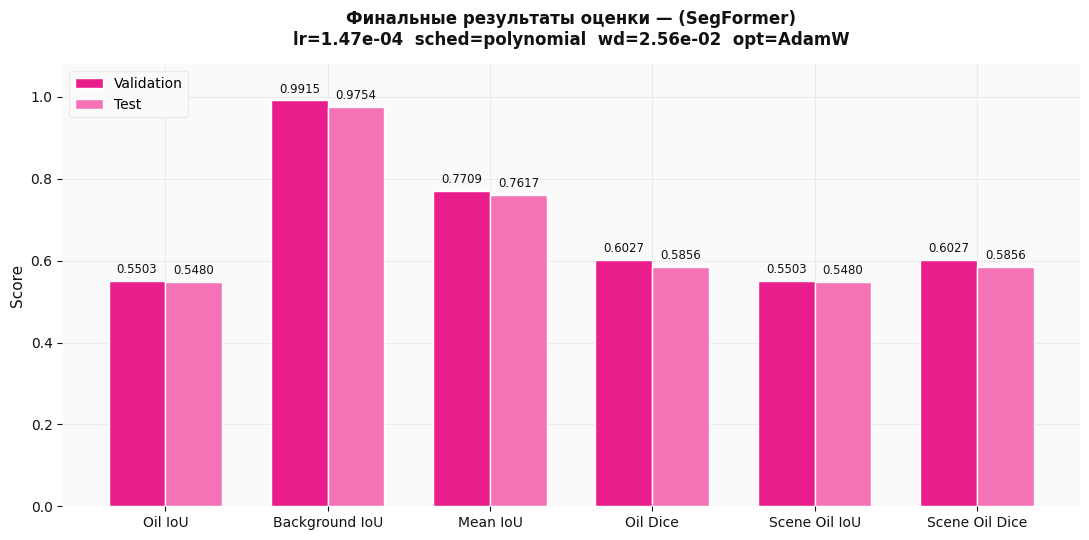

In [16]:
# График таблицы саммари

import json
import numpy as np

with open('segformer_run5_log.json') as f:
    log = json.load(f)

val_final_metrics  = next(r for r in log if r['phase'] == 'final_val')
test_final_metrics = next(r for r in log if r['phase'] == 'final_test')

metrics_labels = ['Oil IoU', 'Background IoU', 'Mean IoU', 'Oil Dice', 'Scene Oil IoU', 'Scene Oil Dice']
val_values  = [
    val_final_metrics.get('val_oil_iou', float('nan')),
    val_final_metrics.get('val_background_iou', float('nan')),
    val_final_metrics.get('val_mean_iou', float('nan')),
    val_final_metrics.get('val_oil_dice', float('nan')),
    val_final_metrics.get('val_scene_oil_iou', float('nan')),
    val_final_metrics.get('val_scene_oil_dice', float('nan')),
]
test_values = [
    test_final_metrics.get('test_oil_iou', float('nan')),
    test_final_metrics.get('test_background_iou', float('nan')),
    test_final_metrics.get('test_mean_iou', float('nan')),
    test_final_metrics.get('test_oil_dice', float('nan')),
    test_final_metrics.get('test_scene_oil_iou', float('nan')),
    test_final_metrics.get('test_scene_oil_dice', float('nan')),
]

FINAL_BACKBONE = 'mit_b1'
WINNER_CONFIG = dict(LR=1.47e-04, SCHEDULER='polynomial', WEIGHT_DECAY=2.56e-02, OPTIMIZER='AdamW')

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))

bars_val  = ax.bar(x - width/2, val_values,  width, color=C_PINK,      edgecolor='white', label='Validation', zorder=3)
bars_test = ax.bar(x + width/2, test_values, width, color=C_PINK_SOFT, edgecolor='white', label='Test',       zorder=3)

for bars in (bars_val, bars_test):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.012,
                f'{height:.4f}', ha='center', va='bottom',
                fontsize=8.5, color=C_GRAY_DARK)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_title(f'Финальные результаты оценки — (SegFormer)\n'
             f'lr={WINNER_CONFIG["LR"]:.2e}  sched={WINNER_CONFIG["SCHEDULER"]}  '
             f'wd={WINNER_CONFIG["WEIGHT_DECAY"]:.2e}  opt={WINNER_CONFIG["OPTIMIZER"]}',
             fontsize=12)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('final_summary_metrics.png')
plt.show()

### Финальные результаты оценки — SegFormer: сравнительный анализ метрик

**Oil IoU vs Background IoU vs Mean IoU.** Разрыв между Oil IoU (0.548 на тесте) и Background IoU (0.975 на тесте) составляет почти 0.43 - это прямое следствие сильного дисбаланса классов в данных: фон занимает подавляющую часть площади снимков, и модели заведомо проще научиться корректно классифицировать его, чем выделить относительно небольшие и неоднородные по форме области разлива. Mean IoU (0.762 на тесте), будучи простым средним этих двух величин, маскирует эту асимметрию, он выглядит высоким, но это из-за хорошо решённой "лёгкой" части задачи (фону), а не реальному качеству детекции нефти. Это подчёркивает, почему Oil IoU, а не Mean IoU, должен быть основной метрикой при сравнении конфигураций и архитектур в этой задаче

**Oil IoU vs Oil Dice.** Oil Dice (0.586) систематически выше Oil IoU (0.548) на одинаковых данных. Оба показателя измеряют одно и то же качество сегментации с разной чувствительностью к ошибкам: Dice более снисходителен к небольшим несовпадениям границ, IoU - строже. Их близость друг к другу (разница 0.038) говорит о согласованности двух независимых способов измерения одного и того же явления

**Patch-level vs Scene-level метрики.** Oil IoU и Scene Oil IoU совпадают с точностью до четвёртого знака (0.5480 против 0.5480 на тесте) - то же самое верно для пары Oil Dice / Scene Oil Dice. То есть оказатель, рассчитанный на отдельных патчах 512×512, идентичен показателю, рассчитанному после склейки полных сцен 2048×2048. Это означает, что качество модели не зависит от масштаба, на котором проводится оценка - модель одинаково хорошо (или одинаково плохо) работает как на уровне отдельных фрагментов, так и на уровне целых снимков, что исключает скрытые проблемы на границах патчей при стыковке

**Validation vs Test по всем шести метрикам.** Ни одна пара val/test не расходится больше, чем на 0.02 (наибольший разрыв - у Background IoU: 0.9915 против 0.9754, наименьший - у Oil IoU: 0.5503 против 0.5480)